## Astro kod

### Parser

In [2]:
import numpy as np
import scipy as sci
import astropy as aspy
import pandas as pd
import matplotlib.pyplot as plt

from parser import parseFits

# Parsea fits data för de tre AGB-stjärnorna
R_Dor = parseFits("data/RDor/")
R_Leo = parseFits("data/aop_mount/home/wouterv/DATA/AGB_Continuum_files/RLeo/")
W_Hya = parseFits("data/aop_mount/home/wouterv/DATA/AGB_Continuum_files/WHya/")

### Centrum metoder
Beräkna centrum

In [3]:
# Centrum metoder

from center_plots import plotMethods, plotMethods2
from center_methods import getCenters, maxIntensitet, gaussIntensitet, halvaMax, halvaViktad, halvaLSQ, moffat
from astro_data_format import toAstroData, fromAstroData

method_names = {}

stars = {'R_Dor': R_Dor, 'R_Leo': R_Leo, 'W_Hya': W_Hya}
methods = {'MaxInt': maxIntensitet, 'Gauss': gaussIntensitet, 'HalfMax': halvaMax, 'HalfViktad': halvaViktad, 'HalfLSQ': halvaLSQ, 'Moffat': moffat}


star_travel_dict = {}

def calcAllCenterMethods():
    for method_name, method in methods.items():
        for star_name, star in stars.items():
            print(f"Calculating centers for star {star_name}, with method {method_name}")
            centers = getCenters(method, star)
            star_travel_dict[star_name, method_name] = centers
            toAstroData(fname = f"{star_name}_{method_name}.astrom.dat", header=f"name = {star_name} - {method_name}", data=centers)

# Avkommentera för att räkna ut alla centrum... görs helst inte ofta... tar sin lilla stund 💅
#calcAllCenterMethods()

Hämta centrum

In [7]:
R_Dor_MaxInt = fromAstroData(f"R_Dor_MaxInt.astrom.dat")
R_Dor_Gauss = fromAstroData(f"R_Dor_Gauss.astrom.dat")
R_Dor_HalfMax = fromAstroData(f"R_Dor_HalfMax.astrom.dat")
R_Dor_HalfViktad = fromAstroData(f"R_Dor_HalfViktad.astrom.dat")
R_Dor_HalfLSQ = fromAstroData(f"R_Dor_HalfLSQ.astrom.dat")
R_Leo_MaxInt = fromAstroData(f"R_Leo_MaxInt.astrom.dat")
R_Leo_Gauss = fromAstroData(f"R_Leo_Gauss.astrom.dat")
R_Leo_HalfMax = fromAstroData(f"R_Leo_HalfMax.astrom.dat")
R_Leo_HalfViktad = fromAstroData(f"R_Leo_HalfViktad.astrom.dat")
R_Leo_HalfLSQ = fromAstroData(f"R_Leo_HalfLSQ.astrom.dat")
W_Hya_MaxInt = fromAstroData(f"W_Hya_MaxInt.astrom.dat")
W_Hya_Gauss = fromAstroData(f"W_Hya_Gauss.astrom.dat")
W_Hya_HalfMax = fromAstroData(f"W_Hya_HalfMax.astrom.dat")
W_Hya_HalfViktad = fromAstroData(f"W_Hya_HalfViktad.astrom.dat")
W_Hya_HalfLSQ = fromAstroData(f"W_Hya_HalfLSQ.astrom.dat")

ValueError: could not convert string '69d11m21.3163881349623807s' to float64 at row 0, column 2.

### Parallax (+Bootstrap)

In [5]:
import astropy.units as u
import jplephem # Need to install
from astropy.coordinates import solar_system_ephemeris

solar_system_ephemeris.set("jpl")

# Use astropy to get earths barycentric coordinates at time t
def bary_coords(t, ref_t):

    date = aspy.time.Time(t + ref_t, format = 'decimalyear')
    Epos = aspy.coordinates.get_body_barycentric('earth', date)

    X = Epos.x.to(u.au).value
    Y = Epos.y.to(u.au).value
    Z = Epos.z.to(u.au).value
    return X, Y, Z


# our model of the motion
def model(t, ref_t, *params):

    ra0, dec0, parallax, pm_ra, pm_dec = params
    X, Y, Z = bary_coords(t, ref_t)

    ra_model = ra0 + (pm_ra/np.cos(dec0))*t + (parallax/np.cos(dec0))*(X*np.sin(ra0) - Y*np.cos(ra0))
    dec_model = dec0 + pm_dec*t + parallax*(X*np.cos(ra0)*np.sin(dec0) + Y*np.sin(ra0)*np.sin(dec0) - Z*np.cos(dec0))

    return ra_model, dec_model

# Same as model, but without proper motion
def model_wopm(t, ref_t, *params):

    ra0, dec0, parallax, pm_ra, pm_dec = params
    
    X, Y, Z = bary_coords(t, ref_t)

    ra_model = ra0 + (parallax/np.cos(dec0))*(X*np.sin(ra0) - Y*np.cos(ra0))
    dec_model = dec0 + parallax*(X*np.cos(ra0)*np.sin(dec0) + Y*np.sin(ra0)*np.sin(dec0) - Z*np.cos(dec0))

    return ra_model, dec_model

# Take observations, and remove its proper motion
def model_subtract_pm(t, ras, decs, *params):
    
    ra0, dec0, parallax, pm_ra, pm_dec = params
        
    ra_sub_pm = ras - ((pm_ra/np.cos(dec0)) * t)
    dec_sub_pm = decs - (pm_dec * t)
    #print(f'ras before: {ras}, ras after {ra_sub_pm}')
    #print(f'decs before: {decs}, decs after {dec_sub_pm}')
    return ra_sub_pm, dec_sub_pm


# residuals to use with least square fitting
def residuals(params, t, ref_t, ras, decs):
    
    ra_model, dec_model = model(t, ref_t, *params)

    residual_ra = (ras - ra_model) * np.cos(dec_model)
    residual_dec = decs - dec_model

    return np.concatenate([residual_ra, residual_dec])


# Function to fit for parameters
def fit_model(t, ref_t, ras, decs, initial, bounds):

    result = sci.optimize.least_squares(residuals, initial,  args = (t, ref_t, ras, decs), max_nfev=5000, bounds = bounds)

    return result

# Function for using bootstrap to get uncertainties in data
def bootstrap(t, ref_t, ras, decs, result, bounds, n_boot=1000):
    
    ra_model, dec_model = model(t, ref_t, *result.x)

    res_ra = ras - ra_model
    res_dec = decs - dec_model

    n = len(t)

    param_samples = []
    
    for i in range(n_boot):
        idx = np.random.randint(0,n,n)

        ra_boot = ra_model + res_ra[idx]
        dec_boot = dec_model + res_dec[idx]
        try:
            res_boot = fit_model(t, ref_t, ra_boot, dec_boot, result.x, bounds)

            param_samples.append(res_boot.x)
        except Exception:
            continue

    print(f'Bootstrap success: {len(param_samples)}/{n_boot}')
    
    return np.array(param_samples)

In [6]:

# Make plots to visualise the result
def makeplots(name, result, t, ref_t, ras, decs):
    # make some hypothetical dates to use for plots
    hypothetical = np.linspace(t[0], t[-1], 1000)
    hypothetical_extended = np.linspace(t[0]-1, t[-1]+1, 1000)
    hypothetical_year = np.linspace(t[0], t[0]+1, 1000)

    ra_mod, dec_mod = model(hypothetical_extended, ref_t, *result.x)
    ra_mod_long, dec_mod_long = model(hypothetical_extended, ref_t, *result.x)
    ra_mod_wopm, dec_mod_wopm = model_wopm(hypothetical_extended, ref_t, *result.x)
    ra_wopm, dec_wopm = model_subtract_pm(t, ras, decs, *result.x)
    
    # convert fitted parameters to mas
    params = np.rad2deg(result.x)*3.6e6 
    ra0, dec0, parallax, pm_ra, pm_dec = params
    
    # Keep ra0 and dec0 in radians
    ra0 = np.deg2rad(ra0/3.6e6) 
    dec0 = np.deg2rad(dec0/3.6e6)

    # Plot how dRA and dDec changes with time, with and without proper motion
    fig, ax = plt.subplots(3,2, figsize = (15,8), dpi = 120)
    fig.subplots_adjust(hspace=0)
    plt.suptitle(name)

    # dDec
    ax[0][0].set_title('With proper motion')
    ax[0][0].plot(hypothetical_extended, 3.6e6*np.rad2deg(dec_mod-dec0), zorder = 0)
    ax[0][0].scatter(t, 3.6e6*np.rad2deg(decs-dec0), color = 'orange', zorder = 1)
    ax[0][0].set_ylabel(r'$\Delta\delta$ [mas]')

    # dRA
    ax[1][0].plot(hypothetical_extended, 3.6e6*np.rad2deg(ra_mod-ra0), zorder = 0)
    ax[1][0].scatter(t, 3.6e6*np.rad2deg(ras-ra0), color = 'orange', zorder = 1)
    ax[1][0].set_xlabel(r'$\Delta t$ [years]')
    ax[1][0].set_ylabel(r'$\Delta\alpha$ [mas]')
    
    ax[0][0].sharex(ax[1][0])
        # Plot how dRA and dDec changes with time, without proper moiton
    ax[0][1].set_title('Without proper motion')
    ax[0][1].plot(hypothetical_extended, 3.6e6*np.rad2deg(dec_mod_wopm-dec0))
    ax[0][1].scatter(t, 3.6e6*np.rad2deg(dec_wopm-dec0), color = 'orange')
    ax[0][1].set_ylabel(r'$\Delta\delta$ [mas]')


    ax[1][1].plot(hypothetical_extended, 3.6e6*np.rad2deg(ra_mod_wopm-ra0))
    ax[1][1].scatter(t, 3.6e6*np.rad2deg(ra_wopm-ra0), color = 'orange')
    ax[1][1].set_ylabel(r'$\Delta\alpha$ [mas]')

    ax[1][0].sharex(ax[1][1])
    ax[1][0].set_xlabel(r'$\Delta t$ [years]')    
    ax[1][1].set_xlabel(r'$\Delta t$ [years]')

    # Plot how the star moves on the sky, dRA vs dDec, with and without proper motion    
    # With proper motion
    ax[2][0].plot(3.6e6*np.rad2deg(ra_mod_long-ra0), 3.6e6*np.rad2deg(dec_mod_long-dec0), zorder = 0)
    ax[2][0].scatter(3.6e6*np.rad2deg(ras-ra0), 3.6e6*np.rad2deg(decs-dec0), color = 'orange', zorder = 1)
    ax[2][0].axis('equal') # 1 grad RA = 1 grad dec
    ax[2][0].invert_xaxis()
    ax[2][0].set_title(r'Dec vs RA with proper motion')
    ax[2][0].set_xlabel(r'$\Delta\alpha$ [mas]')
    ax[2][0].set_ylabel(r'$\Delta\delta$ [mas]')


    # Without proper motion
    ax[2][1].plot(3.6e6*np.rad2deg(ra_mod_wopm-ra0), 3.6e6*np.rad2deg(dec_mod_wopm-dec0), zorder = 0)
    ax[2][1].scatter(3.6e6*np.rad2deg(ra_wopm-ra0), 3.6e6*np.rad2deg(dec_wopm-dec0), color = 'orange', zorder = 1)
    ax[2][1].axis('equal') # 1 grad RA = 1 grad dec
    ax[2][1].set_title(r'Dec vs RA without proper motion')
    ax[2][1].set_xlabel(r'$\Delta\alpha$ [mas]')
    ax[2][1].set_ylabel(r'$\Delta\delta$ [mas]')

    plt.show()

import matplotlib.gridspec as gridspec

def makeplots2(name, result, t, ref_t, ras, decs):

    hypothetical = np.linspace(t[0], t[-1], 1000)
    hypothetical_extended = np.linspace(t[0]-1, t[-1]+1, 1000)

    ra_mod, dec_mod = model(hypothetical_extended, ref_t, *result.x)
    ra_mod_long, dec_mod_long = model(hypothetical_extended, ref_t, *result.x)
    ra_mod_wopm, dec_mod_wopm = model_wopm(hypothetical_extended, ref_t, *result.x)
    ra_wopm, dec_wopm = model_subtract_pm(t, ras, decs, *result.x)
    
    params = np.rad2deg(result.x)*3.6e6 
    ra0, dec0, parallax, pm_ra, pm_dec = params
    
    ra0 = np.deg2rad(ra0/3.6e6) 
    dec0 = np.deg2rad(dec0/3.6e6)

    fig = plt.figure(figsize=(15, 10), dpi=120)
    plt.suptitle(name)

    # Outer grid: 2 blocks (top + bottom)
    outer = gridspec.GridSpec(2, 1, height_ratios=[2, 2], hspace=0.4)

    # Top block (2x2, no spacing)
    top = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[0], hspace=0)

    ax00 = fig.add_subplot(top[0, 0])
    ax10 = fig.add_subplot(top[1, 0], sharex=ax00)

    ax01 = fig.add_subplot(top[0, 1])
    ax11 = fig.add_subplot(top[1, 1], sharex=ax01)

    # Bottom block (normal spacing)
    bottom = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1])

    ax20 = fig.add_subplot(bottom[0, 0])
    ax21 = fig.add_subplot(bottom[0, 1])

    # --- PLOTTING (same as your code) ---

    # With proper motion
    ax00.set_title('With proper motion')
    ax00.plot(hypothetical_extended, 3.6e6*np.rad2deg(dec_mod-dec0))
    ax00.scatter(t, 3.6e6*np.rad2deg(decs-dec0), color='orange')
    ax00.set_ylabel(r'$\Delta\delta$ [mas]')
    ax00.tick_params(labelbottom=False)

    ax10.plot(hypothetical_extended, 3.6e6*np.rad2deg(ra_mod-ra0))
    ax10.scatter(t, 3.6e6*np.rad2deg(ras-ra0), color='orange')
    ax10.set_ylabel(r'$\Delta\alpha$ [mas]')
    ax10.set_xlabel(r'$\Delta t$ [years]')

    # Without proper motion
    ax01.set_title('Without proper motion')
    ax01.plot(hypothetical_extended, 3.6e6*np.rad2deg(dec_mod_wopm-dec0))
    ax01.scatter(t, 3.6e6*np.rad2deg(dec_wopm-dec0), color='orange')
    ax01.set_ylabel(r'$\Delta\delta$ [mas]')
    ax01.tick_params(labelbottom=False)

    ax11.plot(hypothetical_extended, 3.6e6*np.rad2deg(ra_mod_wopm-ra0))
    ax11.scatter(t, 3.6e6*np.rad2deg(ra_wopm-ra0), color='orange')
    ax11.set_ylabel(r'$\Delta\alpha$ [mas]')
    ax11.set_xlabel(r'$\Delta t$ [years]')

    # Sky plots (separate spacing!)
    ax20.plot(3.6e6*np.rad2deg(ra_mod_long-ra0), 3.6e6*np.rad2deg(dec_mod_long-dec0))
    ax20.scatter(3.6e6*np.rad2deg(ras-ra0), 3.6e6*np.rad2deg(decs-dec0), color='orange')
    ax20.axis('equal')
    ax20.invert_xaxis()
    ax20.set_title('Dec vs RA with proper motion')
    ax20.set_xlabel(r'$\Delta\alpha$ [mas]')
    ax20.set_ylabel(r'$\Delta\delta$ [mas]')

    ax21.plot(3.6e6*np.rad2deg(ra_mod_wopm-ra0), 3.6e6*np.rad2deg(dec_mod_wopm-dec0))
    ax21.scatter(3.6e6*np.rad2deg(ra_wopm-ra0), 3.6e6*np.rad2deg(dec_wopm-dec0), color='orange')
    ax21.axis('equal')
    ax21.set_title('Dec vs RA without proper motion')
    ax21.set_xlabel(r'$\Delta\alpha$ [mas]')
    ax21.set_ylabel(r'$\Delta\delta$ [mas]')

    plt.show()

### Analys

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 249081267.051 ± 10.215 mas (68% CI: [249081257.395, 249081276.288])
dec0: -223479093.266 ± 4.722 mas (68% CI: [-223479097.641, -223479088.652])
parallax: 25.858 ± 4.187 mas (68% CI: [21.499, 30.103])
pm_ra: -70.045 ± 0.683 mas (68% CI: [-70.646, -69.371])
pm_dec: -75.960 ± 0.777 mas (68% CI: [-76.708, -75.230])
Distance: 29.509 ± 3.646 parsec

Best fit results:
ra0: 249081267.802 ± 11.225 mas
dec0: -223479093.285 ± 4.889 mas
parallax: 25.561 ± 4.362 mas
pm_ra: -70.075 ± 0.794 mas
pm_dec: -75.984 ± 0.808 mas
Distance: 39.121 ± 6.675 parsec


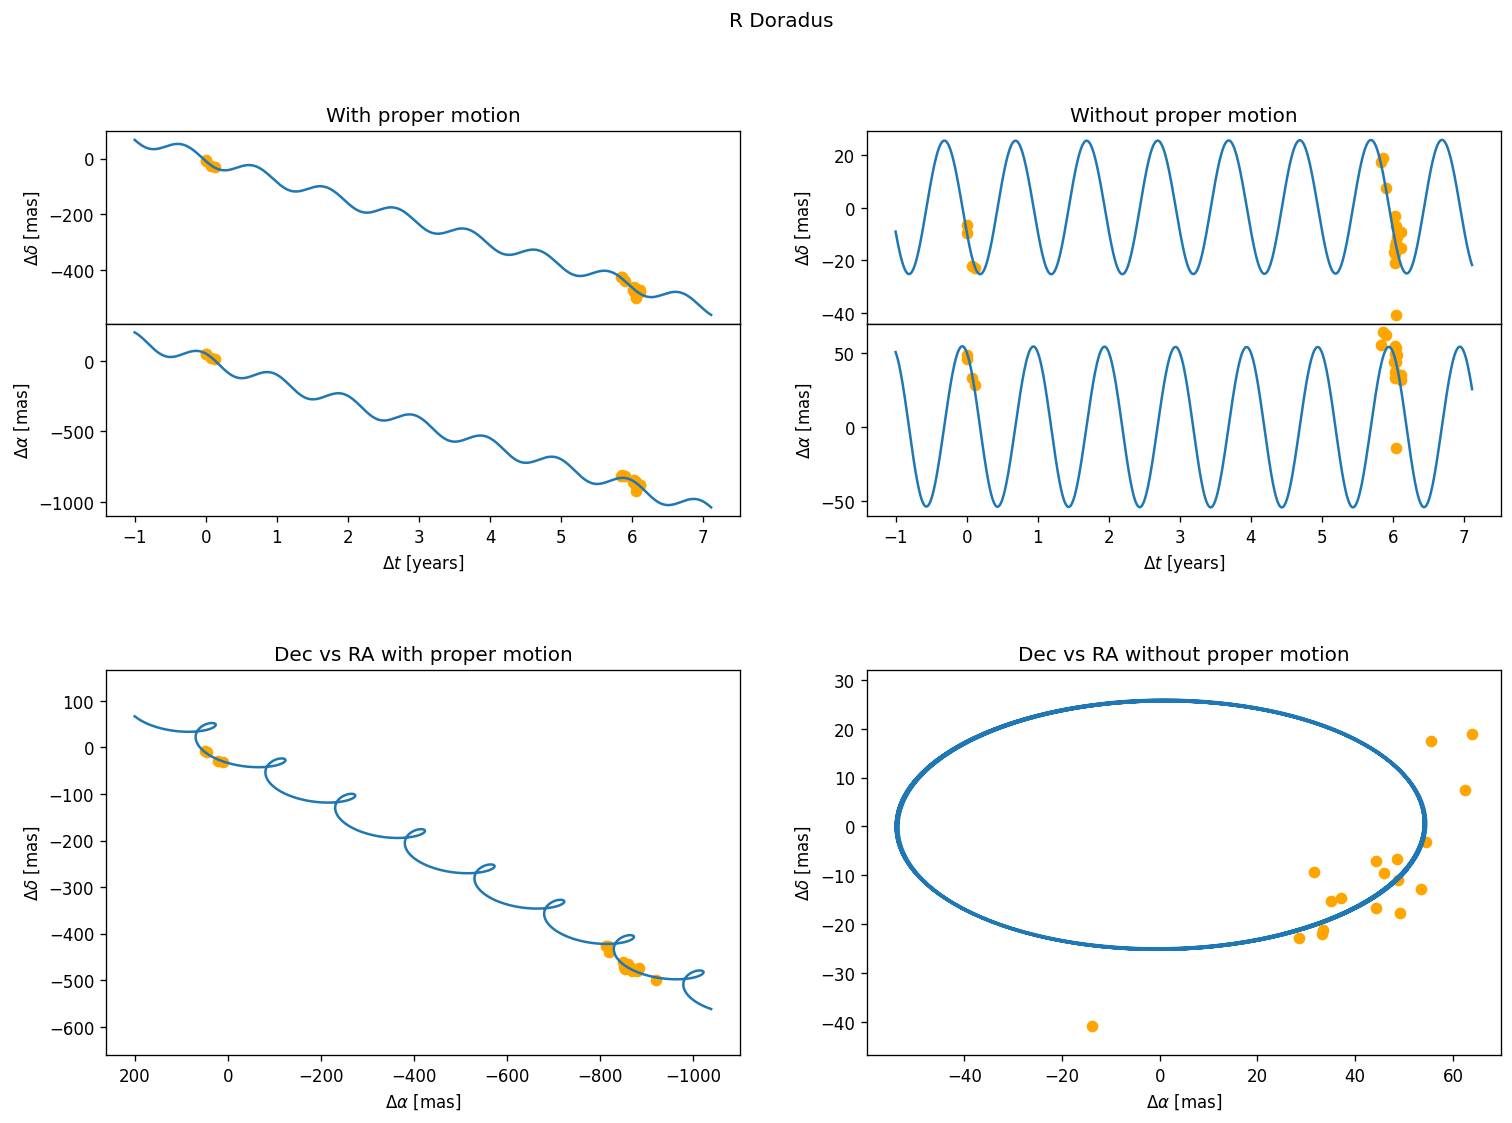

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 249081275.176 ± 6.919 mas (68% CI: [249081268.295, 249081281.576])
dec0: -223479099.204 ± 4.903 mas (68% CI: [-223479103.722, -223479094.173])
parallax: 18.649 ± 3.756 mas (68% CI: [15.231, 22.080])
pm_ra: -69.533 ± 0.302 mas (68% CI: [-69.836, -69.235])
pm_dec: -74.689 ± 0.824 mas (68% CI: [-75.470, -73.908])
Distance: 33.660 ± 4.255 parsec

Best fit results:
ra0: 249081275.769 ± 9.217 mas
dec0: -223479099.393 ± 4.015 mas
parallax: 18.323 ± 3.582 mas
pm_ra: -69.536 ± 0.652 mas
pm_dec: -74.690 ± 0.664 mas
Distance: 54.575 ± 10.667 parsec


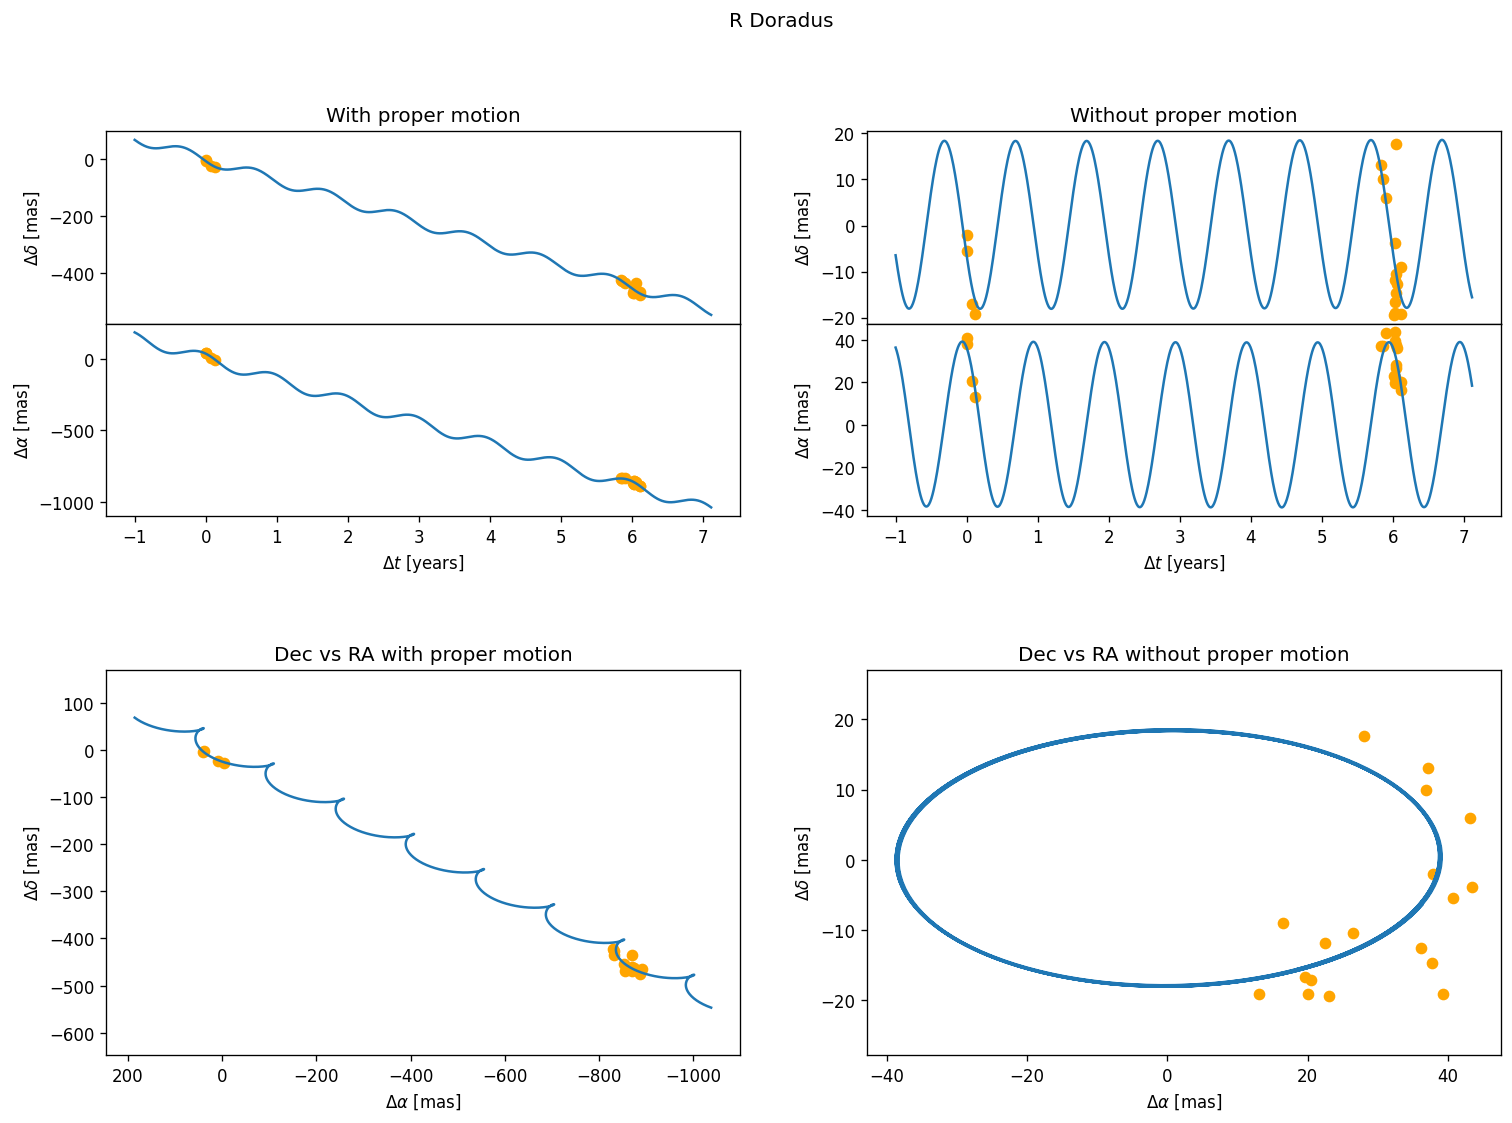

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 249081275.299 ± 6.079 mas (68% CI: [249081269.475, 249081281.032])
dec0: -223479099.232 ± 4.243 mas (68% CI: [-223479103.288, -223479095.049])
parallax: 18.355 ± 3.323 mas (68% CI: [15.180, 21.304])
pm_ra: -69.563 ± 0.266 mas (68% CI: [-69.839, -69.298])
pm_dec: -74.813 ± 0.715 mas (68% CI: [-75.496, -74.133])
Distance: 42.596 ± 6.029 parsec

Best fit results:
ra0: 249081275.294 ± 8.302 mas
dec0: -223479099.137 ± 3.616 mas
parallax: 18.316 ± 3.226 mas
pm_ra: -69.558 ± 0.587 mas
pm_dec: -74.821 ± 0.598 mas
Distance: 54.598 ± 9.616 parsec


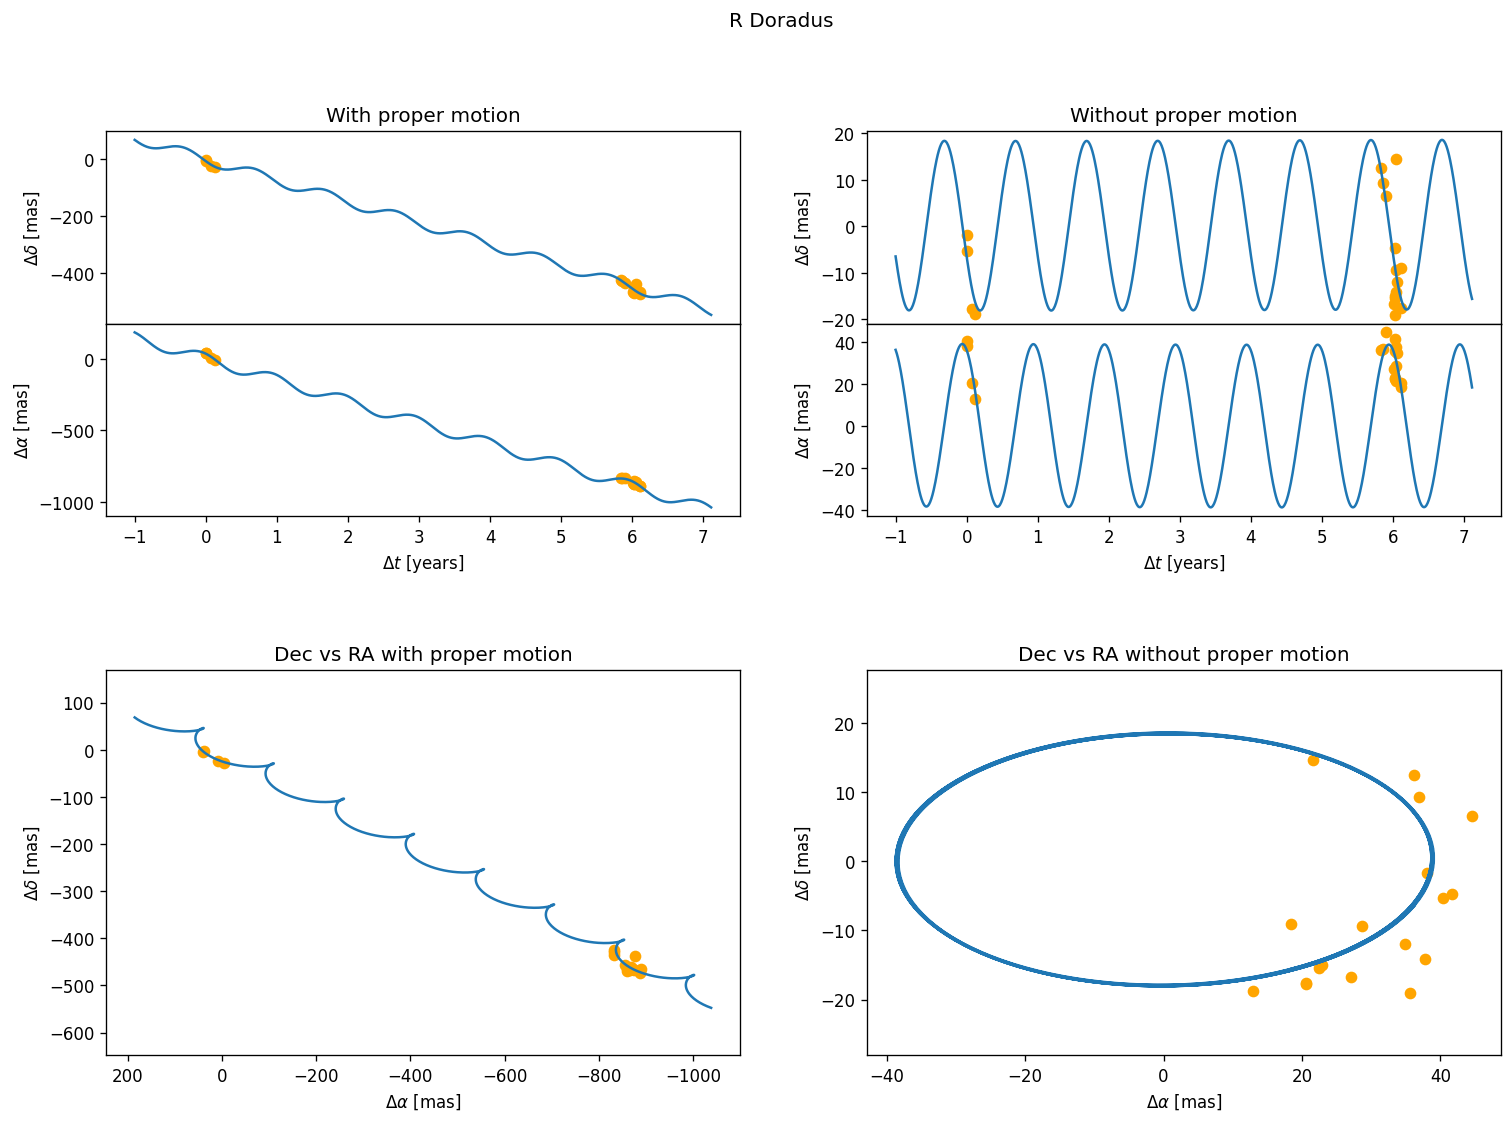

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 249081275.099 ± 5.949 mas (68% CI: [249081269.331, 249081280.692])
dec0: -223479098.842 ± 4.410 mas (68% CI: [-223479103.020, -223479094.525])
parallax: 18.555 ± 3.343 mas (68% CI: [15.517, 21.489])
pm_ra: -69.575 ± 0.269 mas (68% CI: [-69.850, -69.310])
pm_dec: -74.868 ± 0.763 mas (68% CI: [-75.553, -74.172])
Distance: 47.986 ± 7.697 parsec

Best fit results:
ra0: 249081275.468 ± 8.250 mas
dec0: -223479099.184 ± 3.593 mas
parallax: 18.320 ± 3.206 mas
pm_ra: -69.568 ± 0.584 mas
pm_dec: -74.815 ± 0.594 mas
Distance: 54.586 ± 9.552 parsec


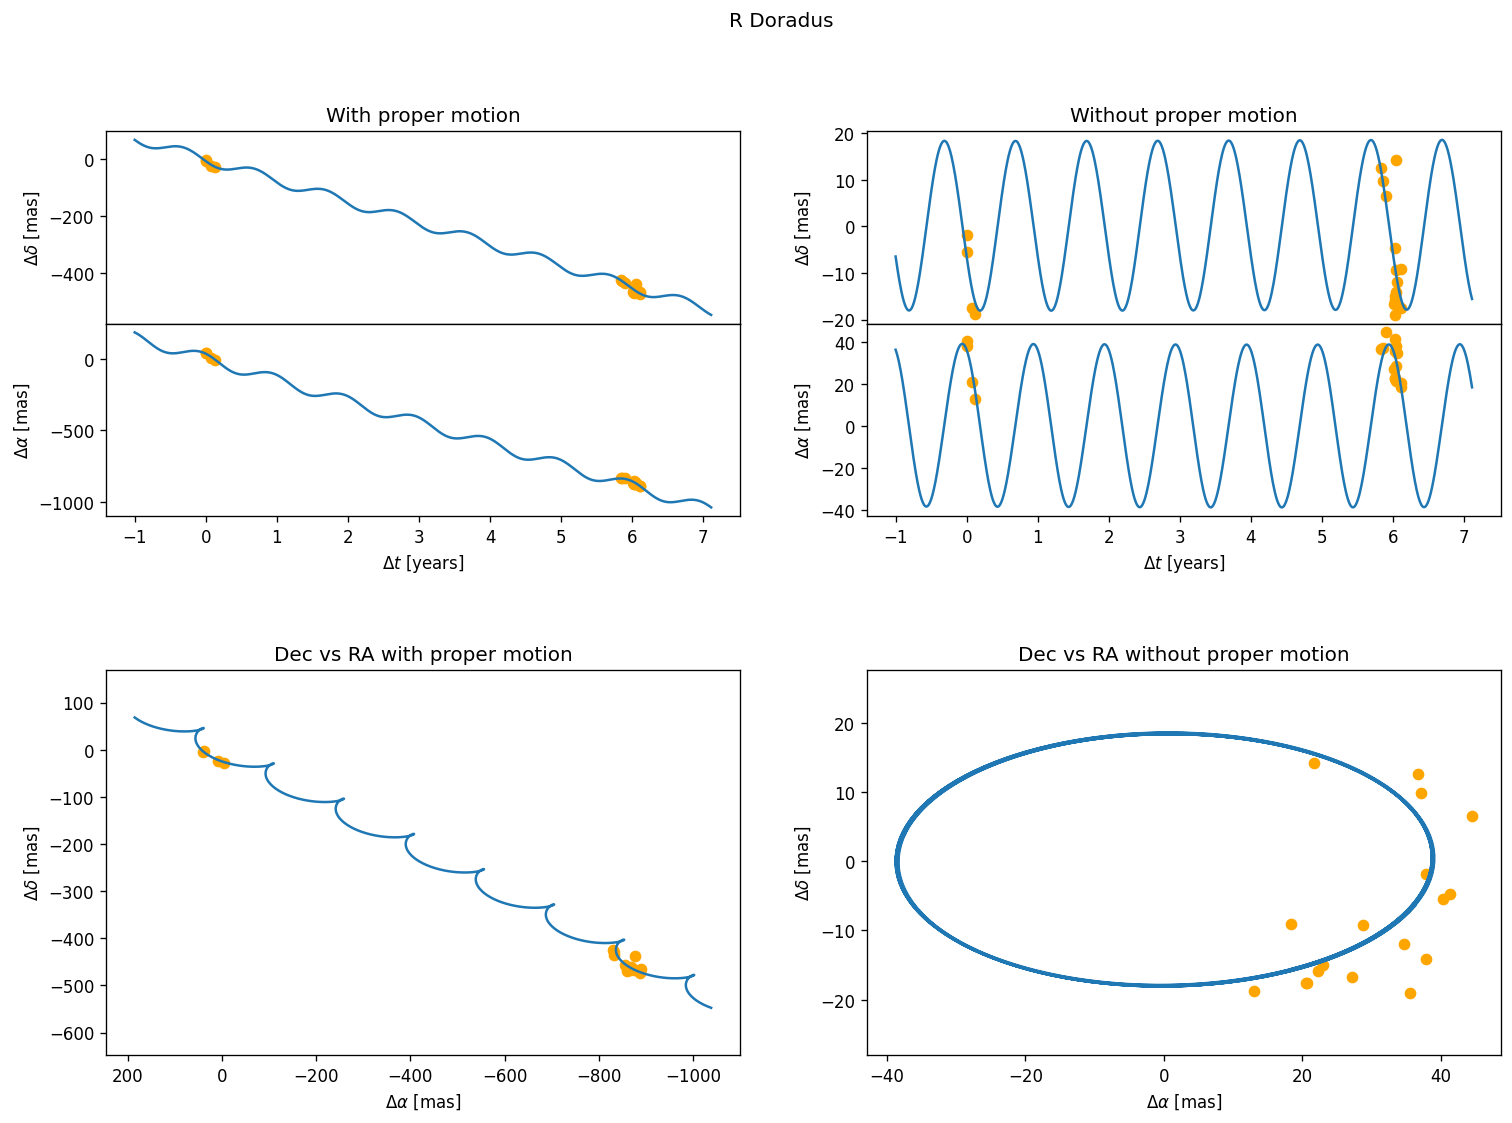

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 249081274.636 ± 6.383 mas (68% CI: [249081268.659, 249081280.810])
dec0: -223479098.882 ± 4.427 mas (68% CI: [-223479103.114, -223479094.388])
parallax: 18.712 ± 3.683 mas (68% CI: [15.449, 21.934])
pm_ra: -69.559 ± 0.265 mas (68% CI: [-69.828, -69.284])
pm_dec: -74.823 ± 0.741 mas (68% CI: [-75.547, -74.116])
Distance: 72.839 ± 19.538 parsec

Best fit results:
ra0: 249081275.268 ± 8.302 mas
dec0: -223479099.163 ± 3.616 mas
parallax: 18.316 ± 3.226 mas
pm_ra: -69.558 ± 0.587 mas
pm_dec: -74.821 ± 0.598 mas
Distance: 54.598 ± 9.616 parsec


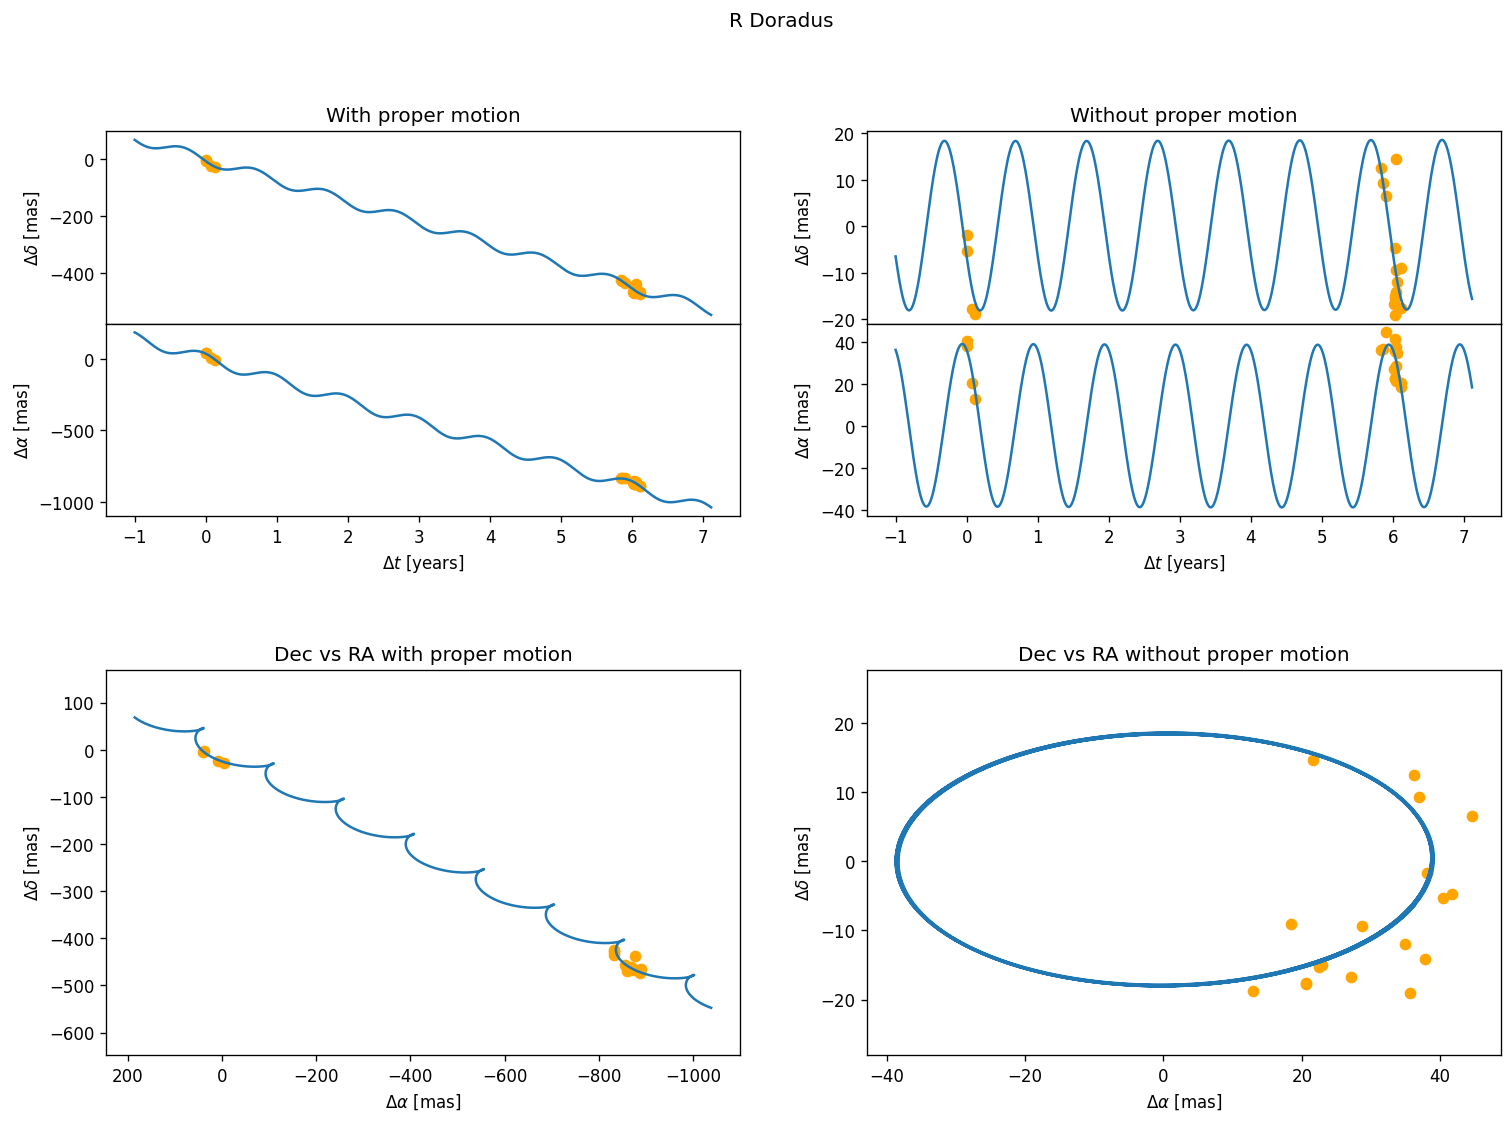

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 746129083.423 ± 3.035 mas (68% CI: [746129080.267, 746129086.441])
dec0: -102124486.605 ± 1.824 mas (68% CI: [-102124488.471, -102124484.715])
parallax: 8.202 ± 2.702 mas (68% CI: [5.799, 10.906])
pm_ra: -49.209 ± 0.446 mas (68% CI: [-49.631, -48.786])
pm_dec: -61.029 ± 0.253 mas (68% CI: [-61.277, -60.761])
Distance: 110.600 ± 33.046 parsec

Best fit results:
ra0: 746129083.556 ± 2.912 mas
dec0: -102124486.613 ± 2.275 mas
parallax: 7.723 ± 3.279 mas
pm_ra: -49.263 ± 0.477 mas
pm_dec: -61.006 ± 0.321 mas
Distance: 129.485 ± 54.980 parsec


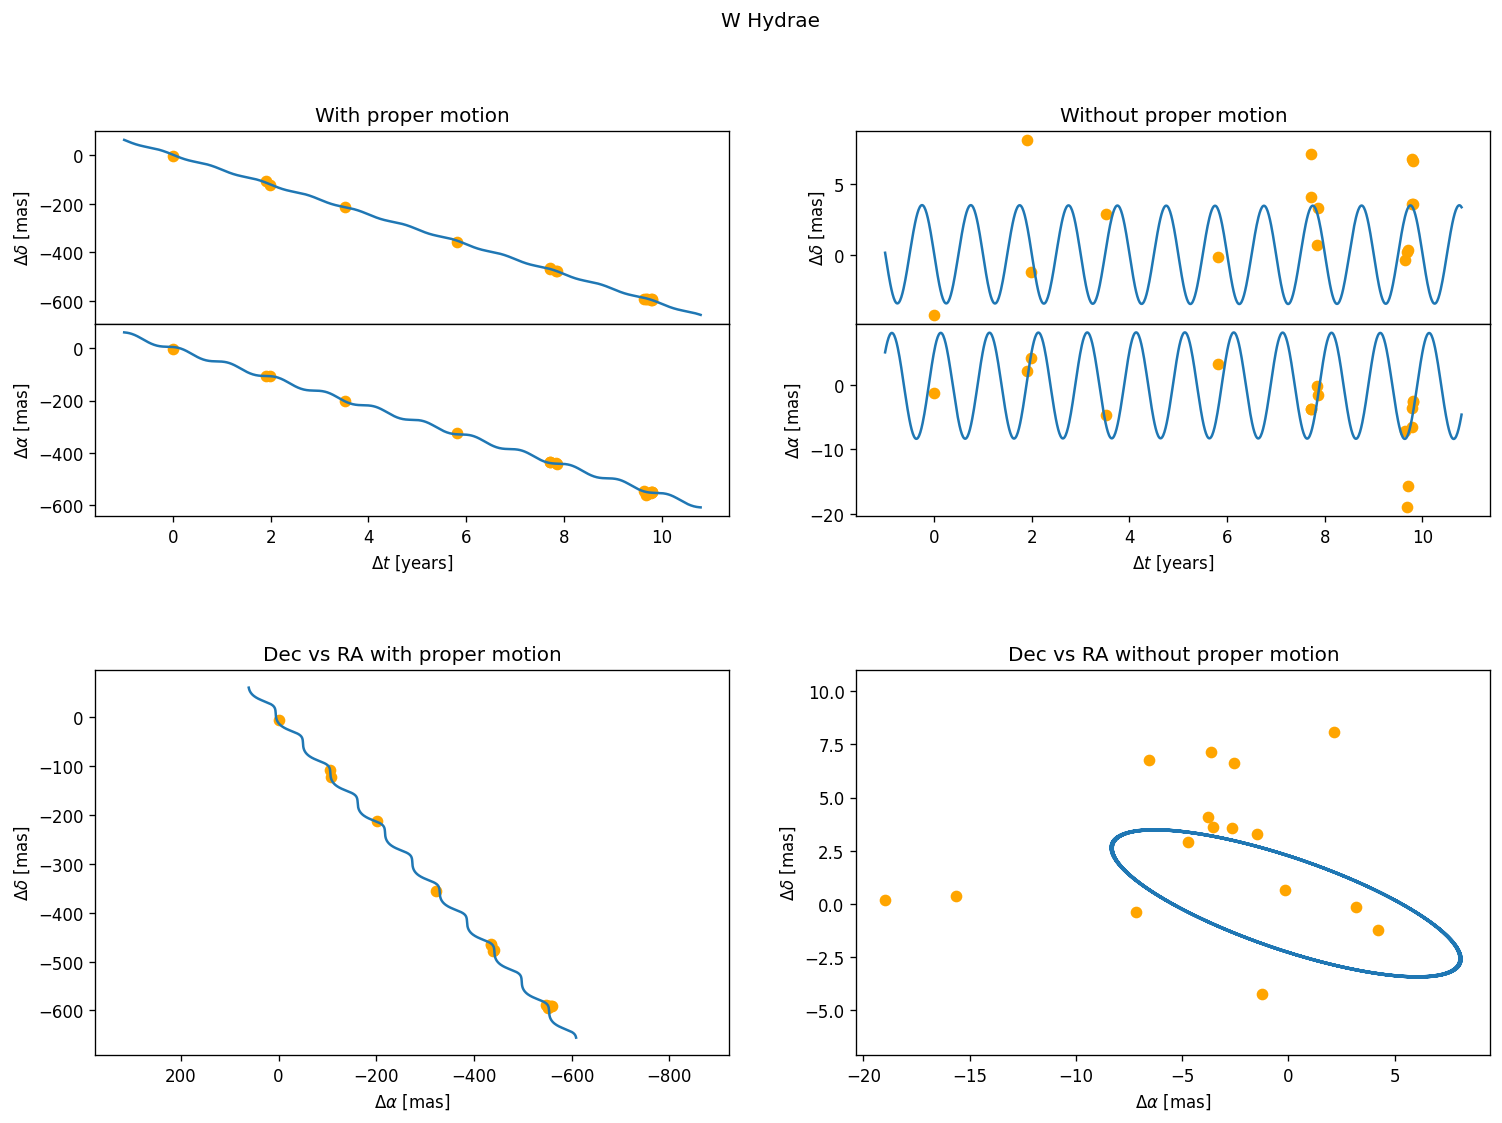

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 746129085.830 ± 1.706 mas (68% CI: [746129084.161, 746129087.471])
dec0: -102124486.591 ± 0.932 mas (68% CI: [-102124487.518, -102124485.651])
parallax: 10.303 ± 1.789 mas (68% CI: [8.613, 12.144])
pm_ra: -49.247 ± 0.270 mas (68% CI: [-49.514, -48.973])
pm_dec: -61.112 ± 0.141 mas (68% CI: [-61.255, -60.972])
Distance: 74.735 ± 9.994 parsec

Best fit results:
ra0: 746129085.889 ± 1.675 mas
dec0: -102124486.612 ± 1.309 mas
parallax: 10.242 ± 1.886 mas
pm_ra: -49.262 ± 0.275 mas
pm_dec: -61.110 ± 0.185 mas
Distance: 97.642 ± 17.985 parsec


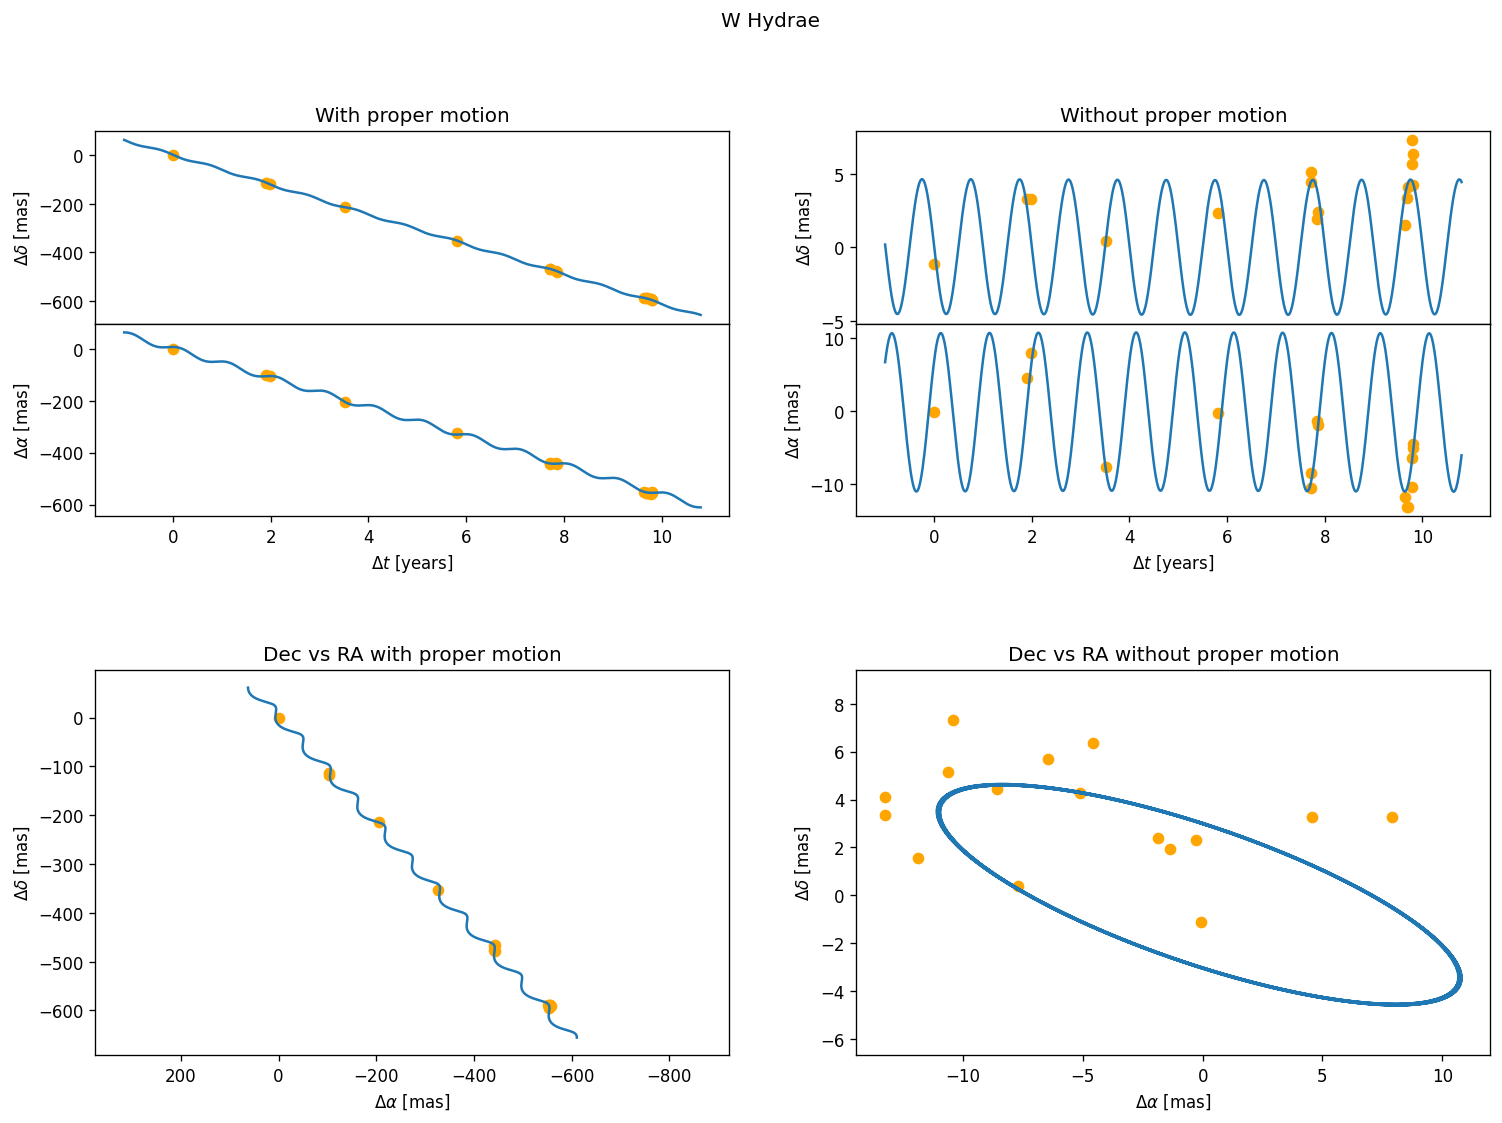

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 746129085.093 ± 1.659 mas (68% CI: [746129083.437, 746129086.776])
dec0: -102124486.962 ± 0.859 mas (68% CI: [-102124487.811, -102124486.088])
parallax: 10.517 ± 1.606 mas (68% CI: [8.999, 12.125])
pm_ra: -49.155 ± 0.251 mas (68% CI: [-49.407, -48.909])
pm_dec: -61.070 ± 0.134 mas (68% CI: [-61.200, -60.934])
Distance: 102.150 ± 16.760 parsec

Best fit results:
ra0: 746129085.187 ± 1.576 mas
dec0: -102124486.994 ± 1.231 mas
parallax: 10.374 ± 1.774 mas
pm_ra: -49.176 ± 0.258 mas
pm_dec: -61.059 ± 0.174 mas
Distance: 96.399 ± 16.486 parsec


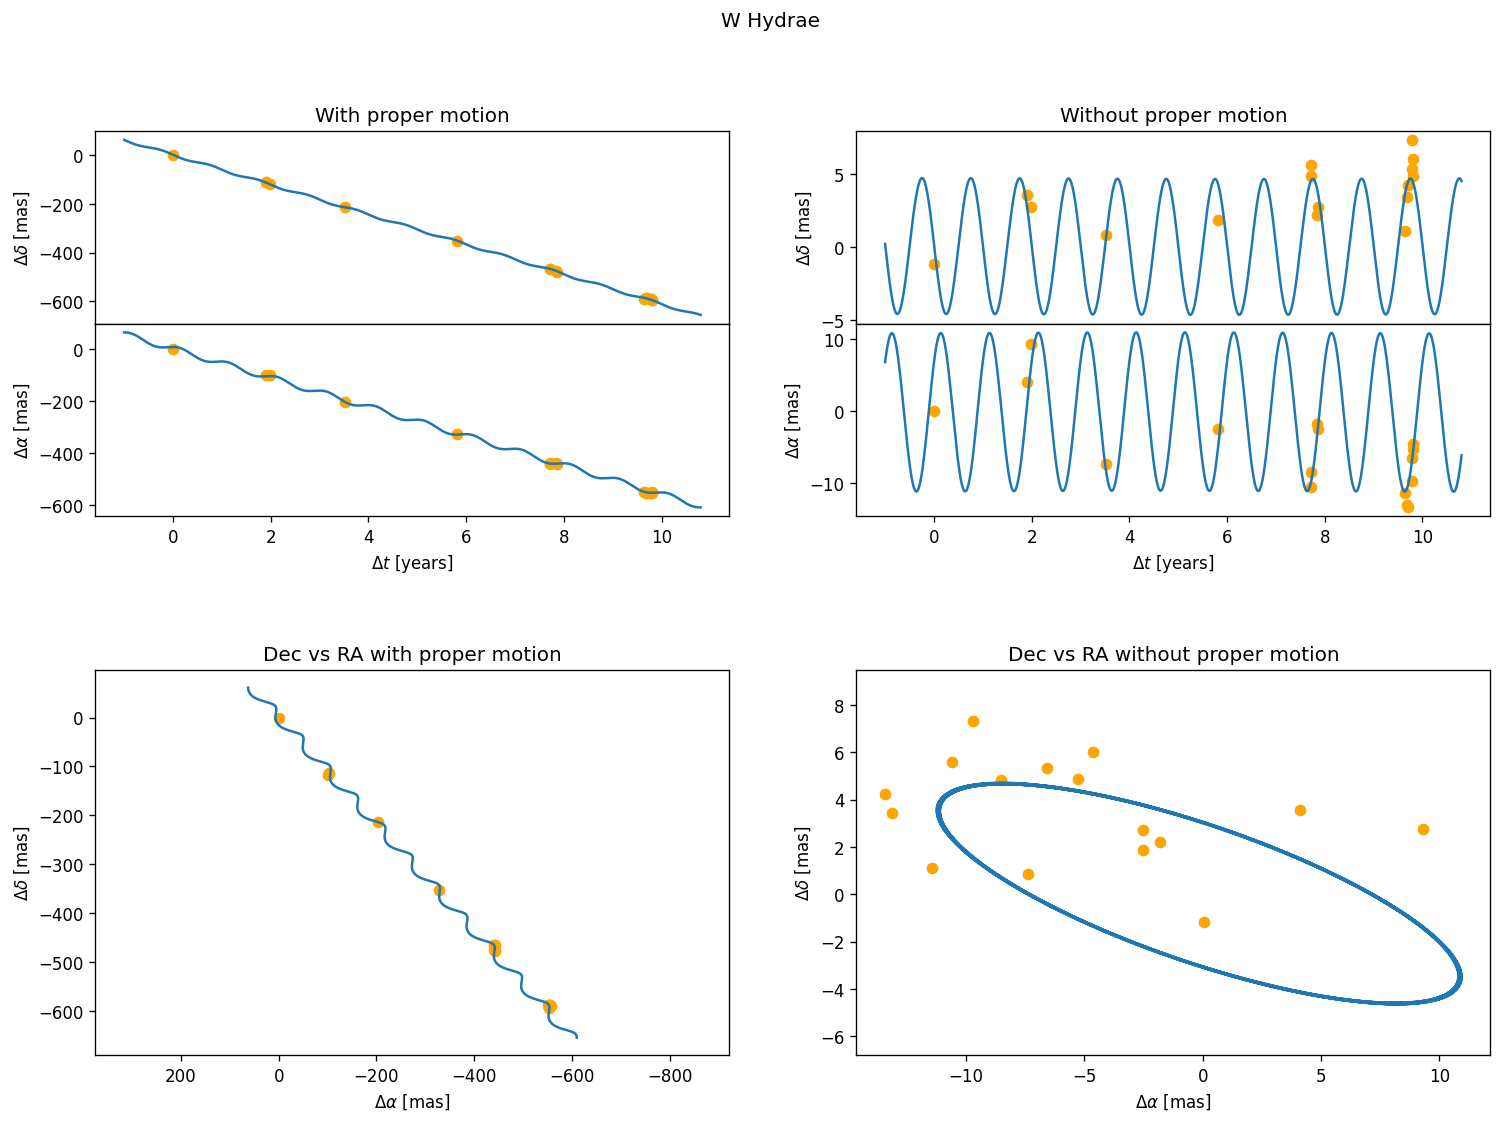

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 746129085.337 ± 1.760 mas (68% CI: [746129083.596, 746129087.067])
dec0: -102124486.979 ± 0.964 mas (68% CI: [-102124487.930, -102124486.017])
parallax: 10.397 ± 1.764 mas (68% CI: [8.695, 11.990])
pm_ra: -49.186 ± 0.275 mas (68% CI: [-49.451, -48.905])
pm_dec: -61.057 ± 0.144 mas (68% CI: [-61.200, -60.910])
Distance: 78.653 ± 10.912 parsec

Best fit results:
ra0: 746129085.368 ± 1.641 mas
dec0: -102124486.989 ± 1.283 mas
parallax: 10.265 ± 1.848 mas
pm_ra: -49.199 ± 0.269 mas
pm_dec: -61.050 ± 0.181 mas
Distance: 97.419 ± 17.542 parsec


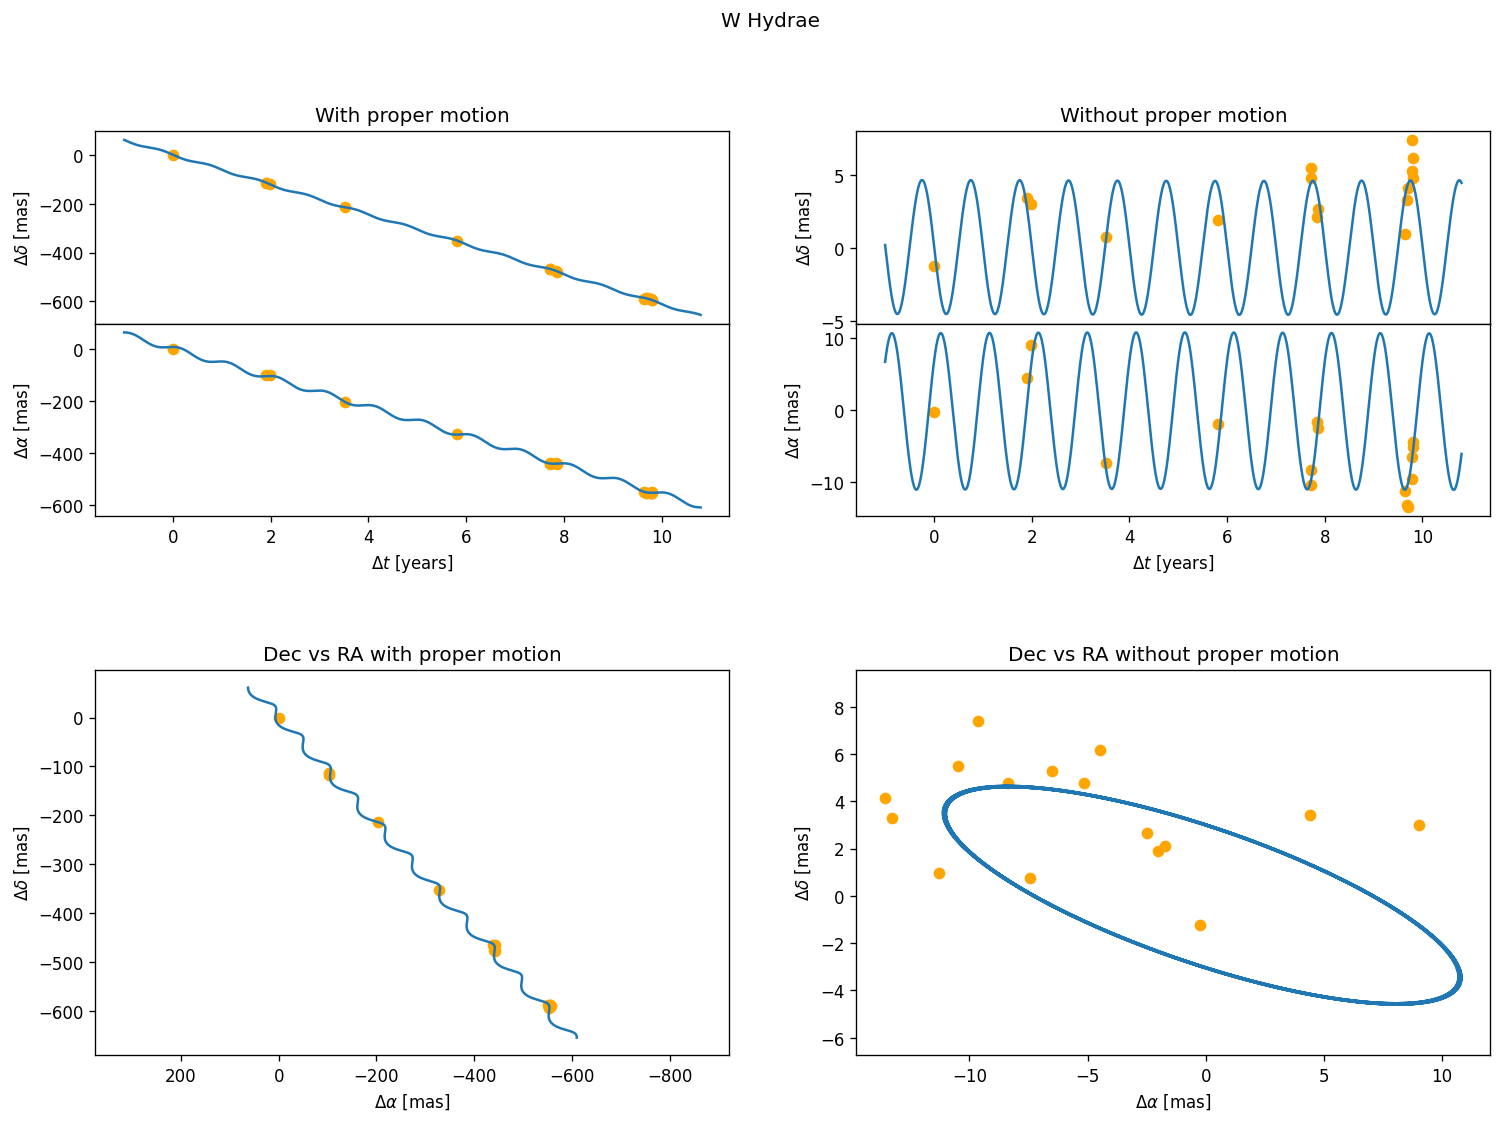

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 746129085.184 ± 1.718 mas (68% CI: [746129083.439, 746129086.892])
dec0: -102124487.039 ± 0.925 mas (68% CI: [-102124487.990, -102124486.111])
parallax: 10.402 ± 1.720 mas (68% CI: [8.805, 11.987])
pm_ra: -49.180 ± 0.275 mas (68% CI: [-49.448, -48.931])
pm_dec: -61.061 ± 0.135 mas (68% CI: [-61.196, -60.934])
Distance: 92.464 ± 14.707 parsec

Best fit results:
ra0: 746129085.161 ± 1.576 mas
dec0: -102124487.020 ± 1.231 mas
parallax: 10.373 ± 1.774 mas
pm_ra: -49.176 ± 0.258 mas
pm_dec: -61.059 ± 0.174 mas
Distance: 96.401 ± 16.488 parsec


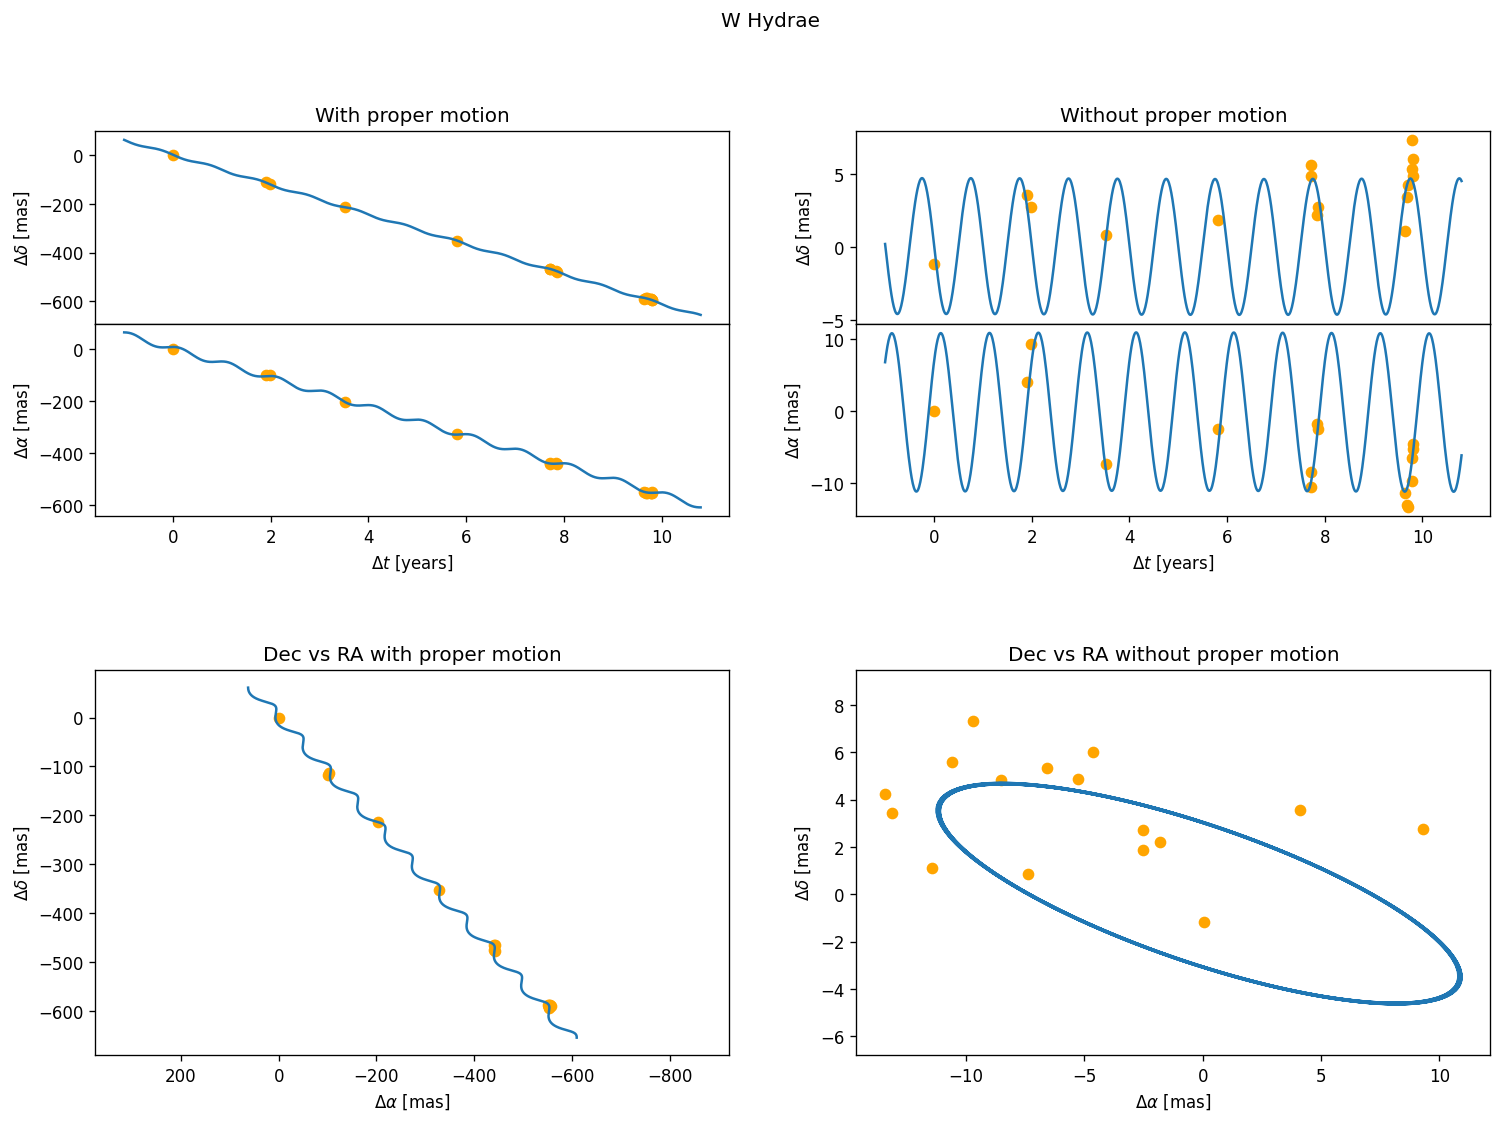

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 528802354.297 ± 2.780 mas (68% CI: [528802351.538, 528802357.216])
dec0: 41142898.222 ± 2.063 mas (68% CI: [41142896.156, 41142900.213])
parallax: 15.931 ± 2.063 mas (68% CI: [13.890, 17.978])
pm_ra: 0.282 ± 0.377 mas (68% CI: [-0.097, 0.669])
pm_dec: -42.852 ± 0.346 mas (68% CI: [-43.209, -42.495])
Distance: 78.901 ± 12.841 parsec

Best fit results:
ra0: 528802354.592 ± 3.565 mas
dec0: 41142898.295 ± 2.285 mas
parallax: 15.805 ± 3.332 mas
pm_ra: 0.257 ± 0.400 mas
pm_dec: -42.857 ± 0.369 mas
Distance: 63.272 ± 13.340 parsec


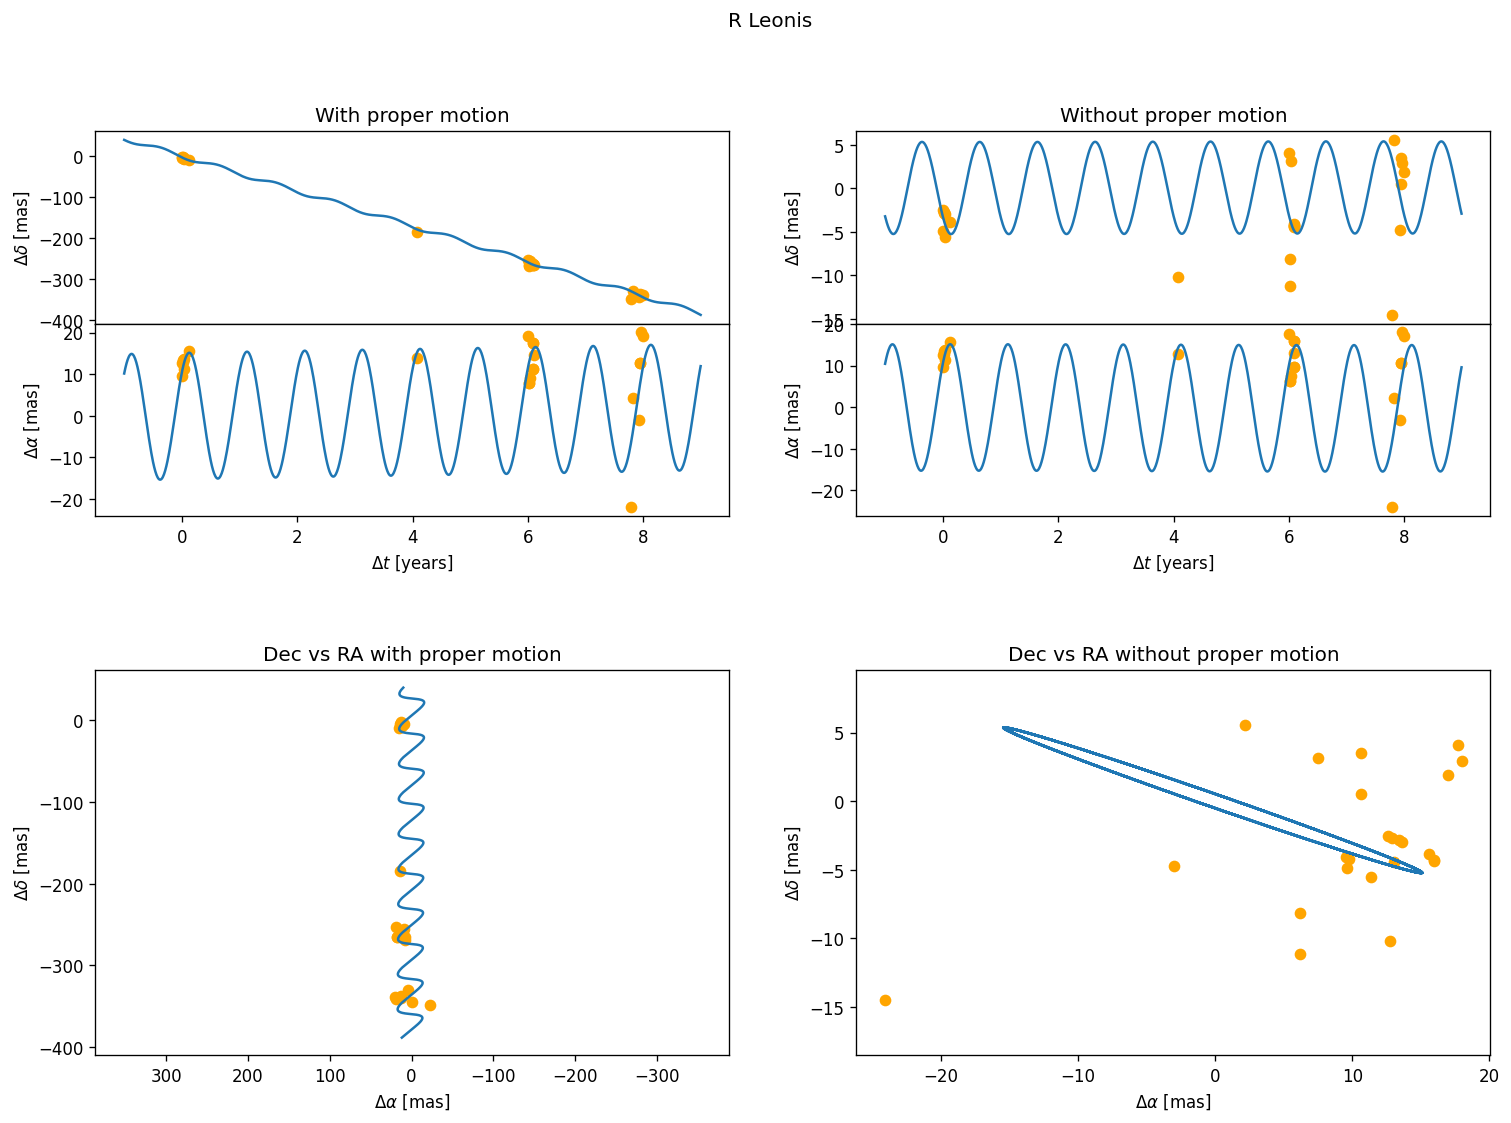

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 528802354.904 ± 3.597 mas (68% CI: [528802351.476, 528802358.339])
dec0: 41142898.840 ± 2.386 mas (68% CI: [41142896.540, 41142901.072])
parallax: 16.328 ± 2.703 mas (68% CI: [13.685, 18.979])
pm_ra: -0.113 ± 0.470 mas (68% CI: [-0.563, 0.352])
pm_dec: -43.144 ± 0.405 mas (68% CI: [-43.535, -42.754])
Distance: 56.726 ± 8.697 parsec

Best fit results:
ra0: 528802355.008 ± 4.484 mas
dec0: 41142898.732 ± 2.874 mas
parallax: 16.208 ± 4.191 mas
pm_ra: -0.123 ± 0.503 mas
pm_dec: -43.136 ± 0.465 mas
Distance: 61.699 ± 15.953 parsec


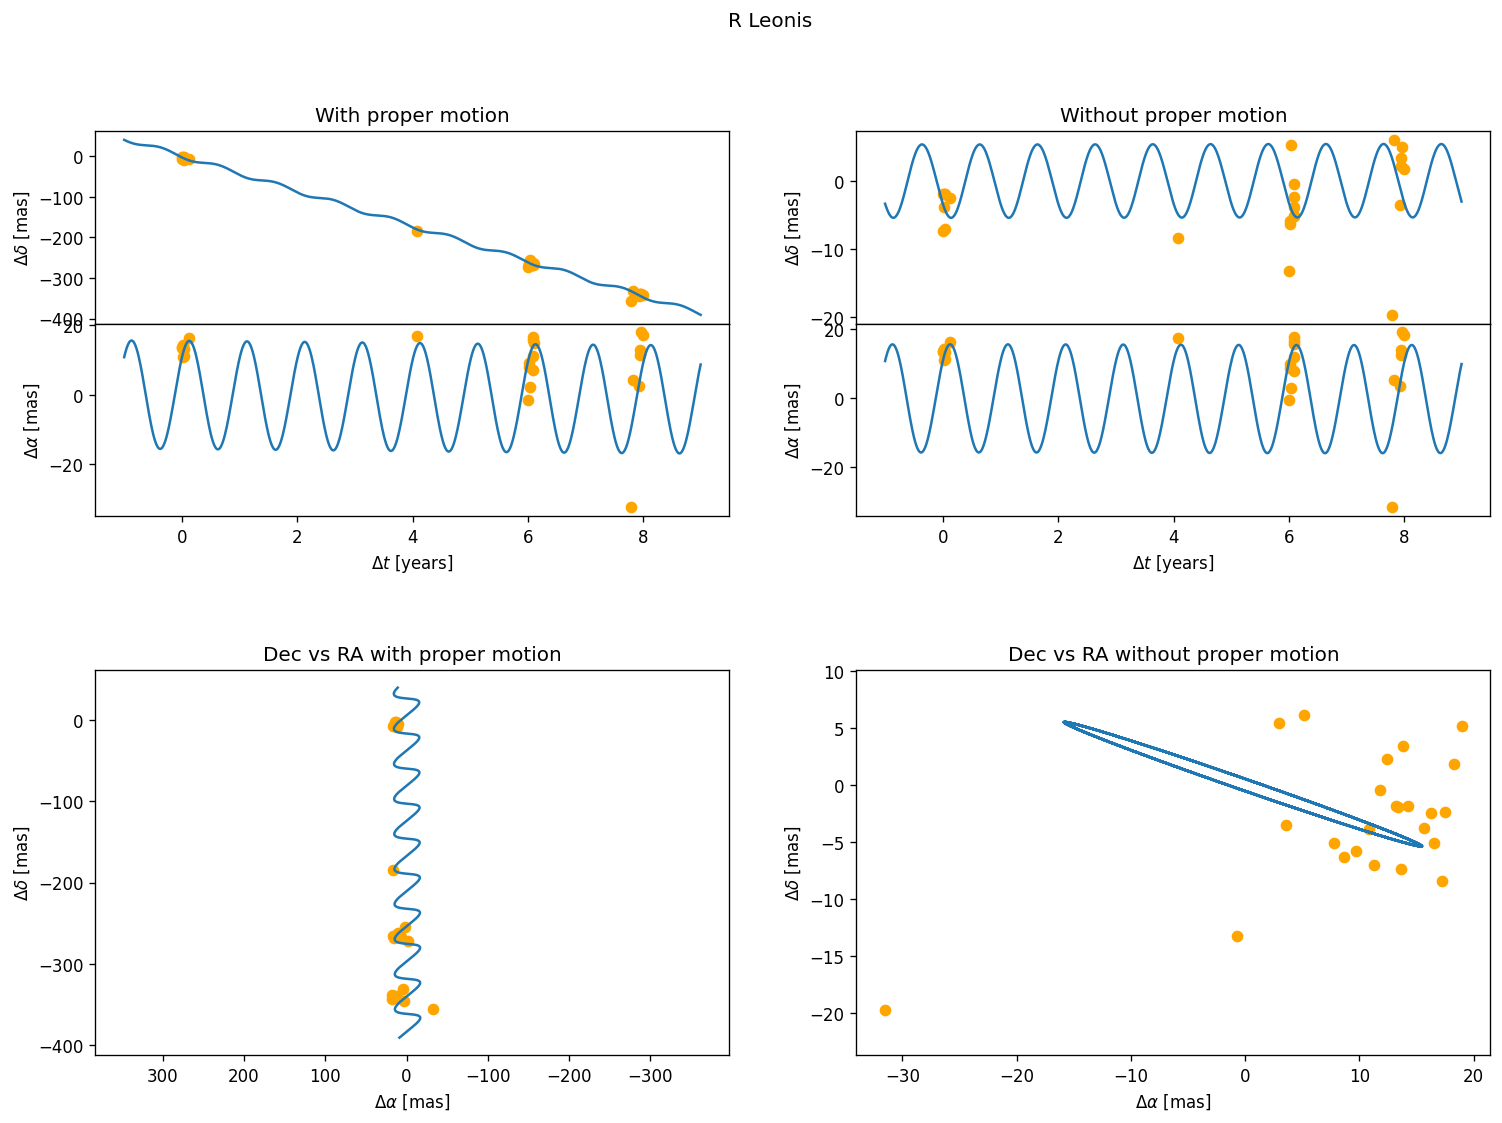

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 528802354.418 ± 3.416 mas (68% CI: [528802351.149, 528802357.708])
dec0: 41142898.610 ± 2.227 mas (68% CI: [41142896.542, 41142900.661])
parallax: 17.099 ± 2.508 mas (68% CI: [14.716, 19.398])
pm_ra: 0.078 ± 0.447 mas (68% CI: [-0.348, 0.531])
pm_dec: -42.947 ± 0.370 mas (68% CI: [-43.312, -42.598])
Distance: 67.163 ± 11.312 parsec

Best fit results:
ra0: 528802354.744 ± 3.966 mas
dec0: 41142898.698 ± 2.542 mas
parallax: 16.857 ± 3.707 mas
pm_ra: 0.057 ± 0.445 mas
pm_dec: -42.964 ± 0.411 mas
Distance: 59.324 ± 13.045 parsec


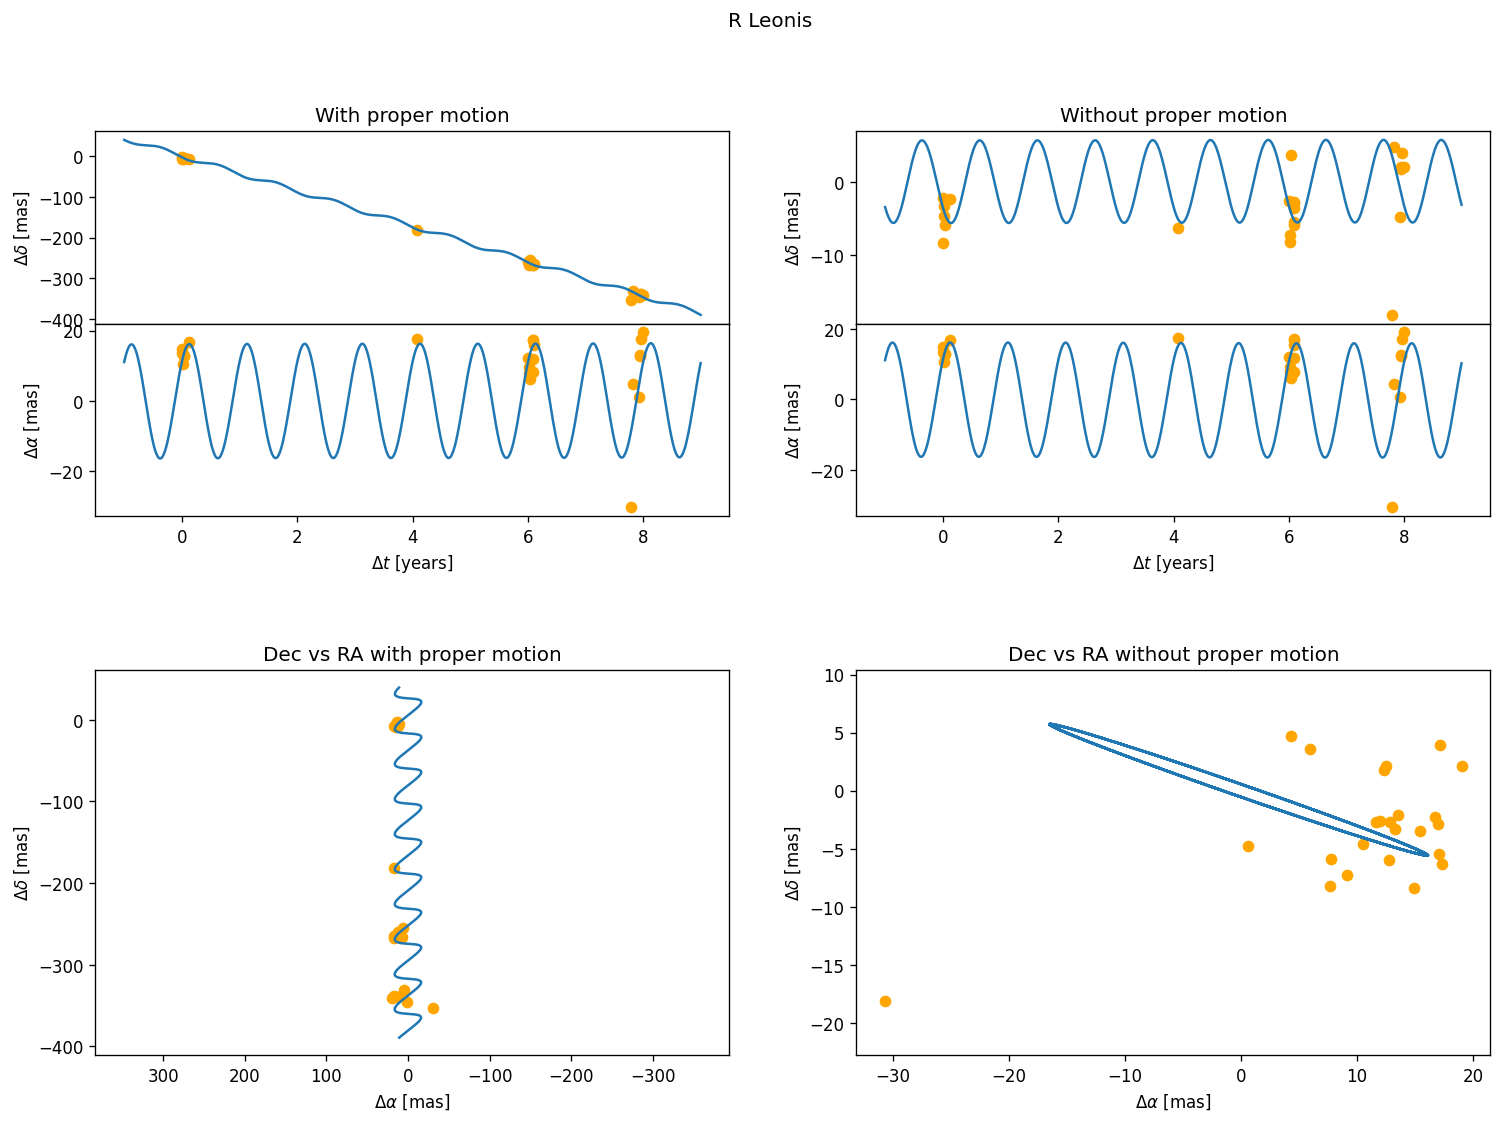

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 528802354.506 ± 3.101 mas (68% CI: [528802351.330, 528802357.678])
dec0: 41142898.597 ± 2.151 mas (68% CI: [41142896.496, 41142900.608])
parallax: 16.976 ± 2.450 mas (68% CI: [14.660, 19.463])
pm_ra: 0.100 ± 0.417 mas (68% CI: [-0.316, 0.511])
pm_dec: -42.940 ± 0.360 mas (68% CI: [-43.263, -42.584])
Distance: 72.309 ± 12.808 parsec

Best fit results:
ra0: 528802354.784 ± 3.945 mas
dec0: 41142898.642 ± 2.528 mas
parallax: 16.820 ± 3.687 mas
pm_ra: 0.068 ± 0.442 mas
pm_dec: -42.950 ± 0.409 mas
Distance: 59.455 ± 13.033 parsec


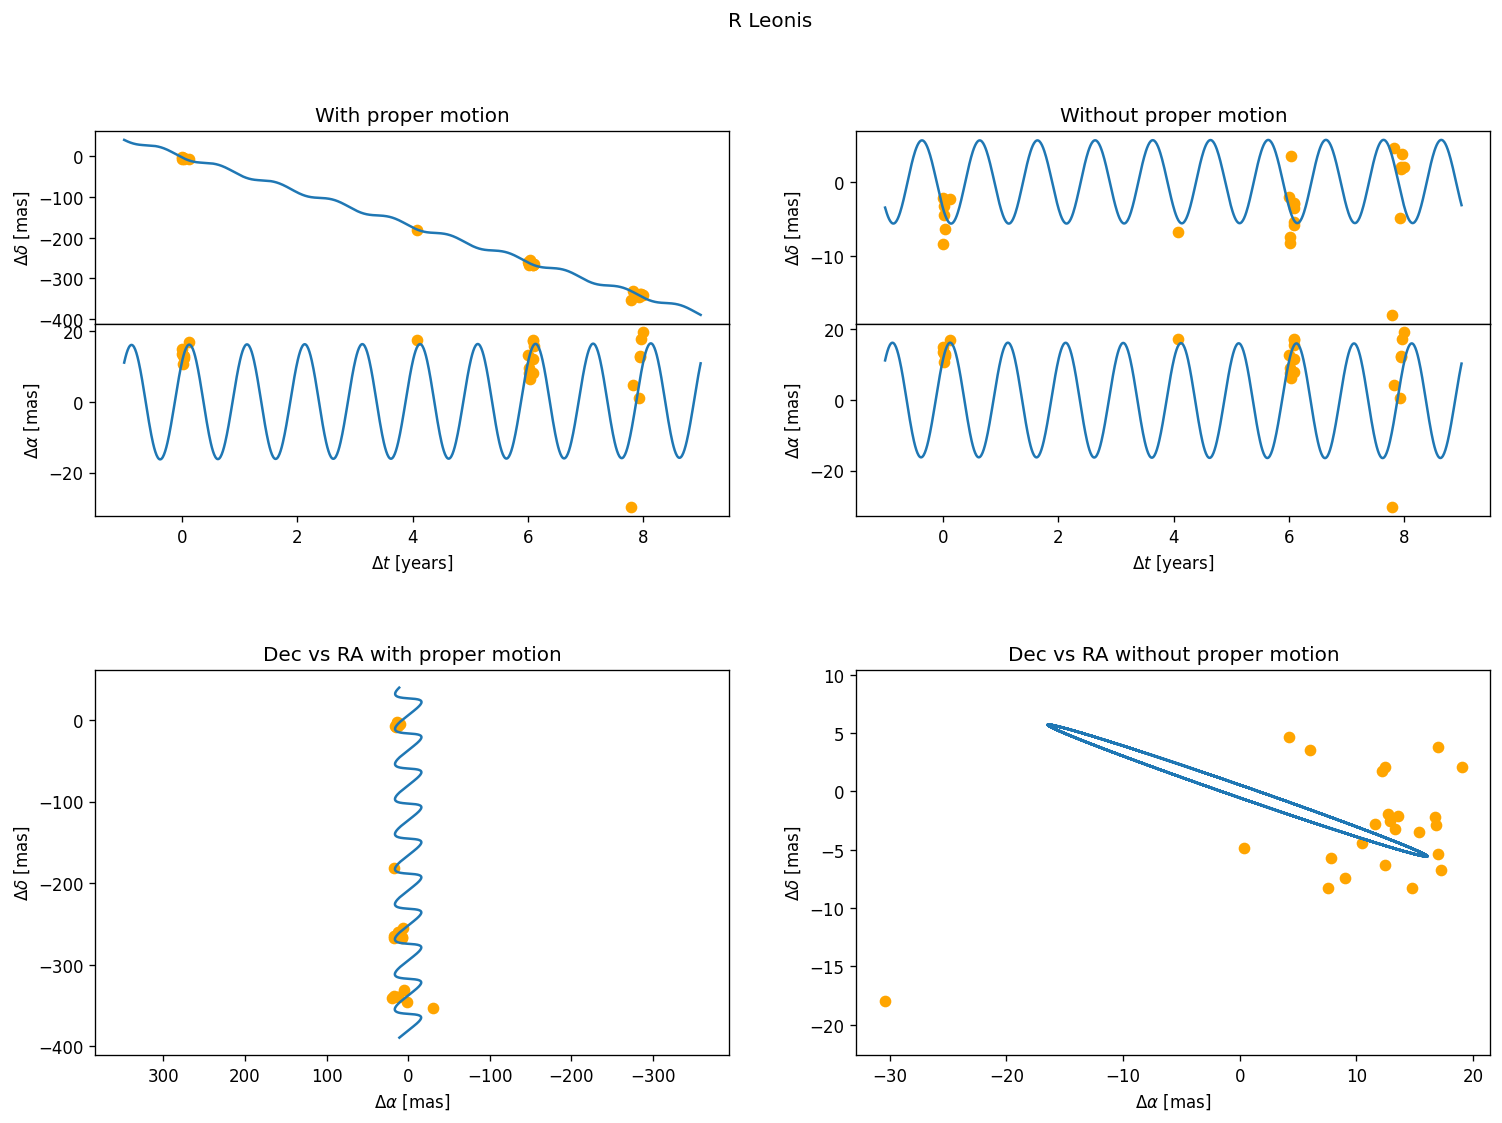

Bootstrap success: 1000/1000

Bootstrap results:
ra0: 528802354.515 ± 3.300 mas (68% CI: [528802351.316, 528802357.836])
dec0: 41142898.705 ± 2.205 mas (68% CI: [41142896.600, 41142900.734])
parallax: 17.060 ± 2.632 mas (68% CI: [14.447, 19.714])
pm_ra: 0.071 ± 0.415 mas (68% CI: [-0.341, 0.483])
pm_dec: -42.967 ± 0.350 mas (68% CI: [-43.302, -42.646])
Distance: 62.273 ± 10.208 parsec

Best fit results:
ra0: 528802354.719 ± 3.966 mas
dec0: 41142898.672 ± 2.542 mas
parallax: 16.856 ± 3.707 mas
pm_ra: 0.056 ± 0.445 mas
pm_dec: -42.964 ± 0.411 mas
Distance: 59.324 ± 13.045 parsec


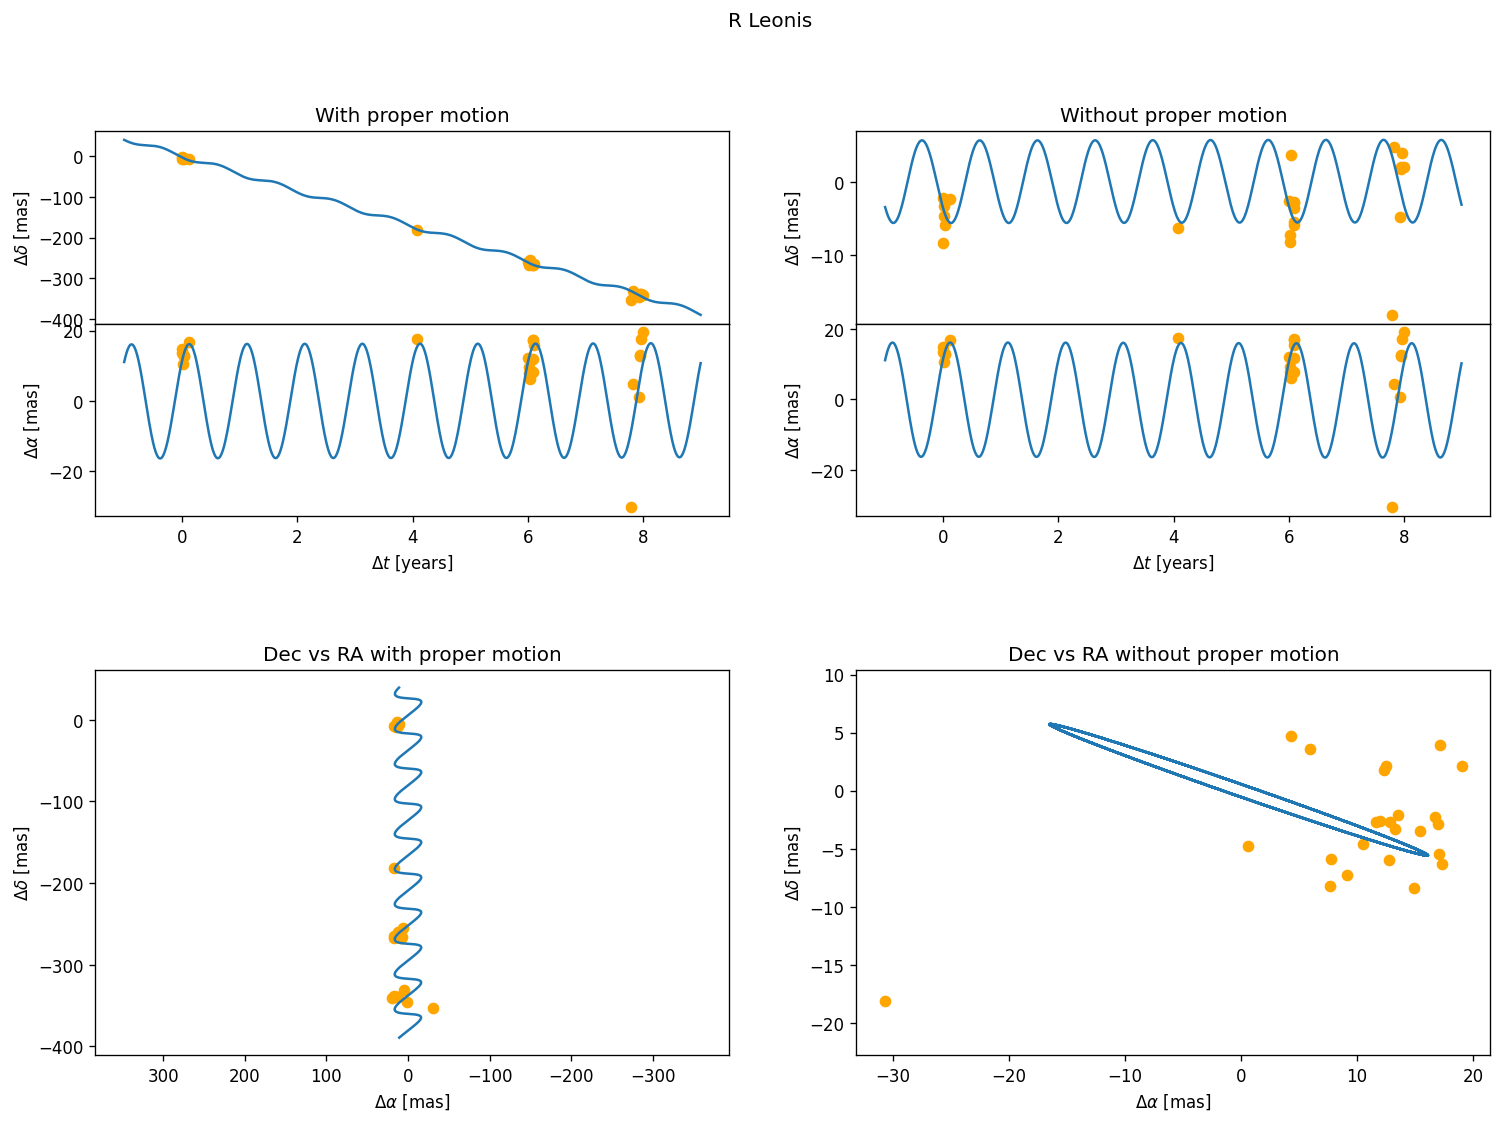

In [7]:
# Choose star to study
stars = {'R Doradus': [R_Dor_MaxInt, R_Dor_Gauss, R_Dor_HalfMax, R_Dor_HalfViktad, R_Dor_HalfLSQ], 
         'W Hydrae': [W_Hya_MaxInt, W_Hya_Gauss, W_Hya_HalfMax, W_Hya_HalfViktad, W_Hya_HalfLSQ], 
         'R Leonis': [R_Leo_MaxInt, R_Leo_Gauss, R_Leo_HalfMax, R_Leo_HalfViktad, R_Leo_HalfLSQ]}
for name, star in stars.items():
    for method in star:
        data = method # 0 = MaxInt, 1 = Gauss


        # Split the data
        date = aspy.time.Time(data[0])
        decs = np.deg2rad(np.asarray(data[2], dtype = float))
        ras = np.deg2rad(np.asarray(data[1], dtype = float))


        # ref_t is our reference epoch
        #ref_t = np.mean(date.decimalyear)
        ref_t = (date.decimalyear)[0]
        t = date.decimalyear - ref_t

        # take an initial guess of the parameters
        masguess = {'R Doradus': 18.31, 'W Hydrae': 10.18, 'R Leonis': 14.06} # initial parallax guess in mas
        initial = [ras[0], decs[0], np.deg2rad(masguess[name]/(3.6e6)), 0., 0.]
        bounds = [(-np.inf, -np.inf, 0., -np.inf, -np.inf), (np.inf, np.inf, np.inf, np.inf, np.inf)]
        # make the fit and get the results
        result = fit_model(t, ref_t, ras, decs, initial, bounds)

        params = np.rad2deg(result.x)*3.6e6 # convert fitted parameters to mas
        ra0, dec0, parallax, pm_ra, pm_dec = params
        ra0 = np.deg2rad(ra0/3.6e6)
        dec0 = np.deg2rad(dec0/3.6e6)


        # Calculate distance
        d_best_fit = 1 / (parallax/1000)
        # Estimate errors
        jacobian = result.jac
        resid = result.fun
        m = len(resid)
        n = len(result.x)
        sigma2 = np.sum(resid**2) / (m - n)
        cov = sigma2 * np.linalg.inv(jacobian.T @ jacobian)

        params_std = np.rad2deg(np.sqrt(np.diag(cov)))*3.6e6

        ra_cal, dec_cal = model(t, ref_t, *result.x)

        # Calculate errors for distance
        d_uncert_best_fit = (1 / ((parallax/1000)**2))*params_std[2]/1000
        # Bootstrap testing
        samples = bootstrap(t, ref_t, ras, decs, result, bounds)
        samples_mas = 3.6e6*np.rad2deg(samples)
        parallax_bootstrap = samples_mas[2][2]

        param_names = ["ra0", "dec0", "parallax", "pm_ra", "pm_dec"]
        d_bootstrap = 1/(parallax_bootstrap/1000)

        means = np.mean(samples_mas, axis=0)
        stds = np.std(samples_mas, axis=0)
        p16 = np.percentile(samples_mas, 16, axis=0)
        p84 = np.percentile(samples_mas, 84, axis=0)

        d_uncert_bootstrap = (1/((parallax_bootstrap/1000)**2))*stds[2]/1000
        print("\nBootstrap results:")
        for i, p_name in enumerate(param_names):
            print(f"{p_name}: {means[i]:.3f} ± {stds[i]:.3f} mas "
                f"(68% CI: [{p16[i]:.3f}, {p84[i]:.3f}])")
        print(f'Distance: {d_bootstrap:.3f} ± {d_uncert_bootstrap:.3f} parsec')


        # print best fit results
        print('\nBest fit results:')
        for i, p_name in enumerate(param_names):
            print(f"{p_name}: {params[i]:.3f} ± {params_std[i]:.3f} mas")

        print(f'Distance: {d_best_fit:.3f} ± {d_uncert_best_fit:.3f} parsec')
        # print(f'Params in rad: {result.x}, params in mas: {params}')
        # print(f'Standard deviation of all parameters in mas: {params_std}')
        # print(f'Parallax: {parallax:.3f} \u00B1 {params_std[2]:.3f} mas')


        makeplots2(name, result, t, ref_t, ras, decs)